# Classification de caractères arméniens historiques (HYE)

## Objectifs
1. **Analyse de features** : HOG, LBP, moments de Hu, features géométriques
2. **Visualisation approfondie** : comprendre quels descripteurs caractérisent chaque classe
3. **Classification par similarité** : KNN et analyse de distance
4. **Interprétation** : identifier les features les plus discriminantes

In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Extraction de features
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
from scipy.spatial.distance import cosine, euclidean, cdist

# Réduction de dimensionalité et visualisation
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Classification et clustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100

In [85]:
def extract_hog_features(image, pixels_per_cell=(8, 8), cells_per_block=(1, 1)):
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    features, hog_image = hog(
        image, 
        orientations=9,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True,
        feature_vector=True
    )
    return features, hog_image


def extract_lbp_features(image, radius=3, n_points=24):
    """
    Extrait les features LBP (Local Binary Patterns)
    - Capture les textures locales
    """
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), density=True)
    return hist


def extract_hu_moments(image):
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    moments = cv2.moments(image)
    hu_moments = cv2.HuMoments(moments).flatten()
    hu_moments = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)
    return hu_moments


def extract_geometric_features(image):
    """
    Extrait des features géométriques simples
    - Ratio aspect, densité de pixels, centroïde, etc.
    """
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Binarisation
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return np.zeros(10)
    
    cnt = max(contours, key=cv2.contourArea)
    
    # Features géométriques
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h if h > 0 else 0
    extent = area / (w * h) if (w * h) > 0 else 0
    
    # Moments
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = M['m10'] / M['m00']
        cy = M['m01'] / M['m00']
    else:
        cx, cy = 0, 0
    
    # Hull
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    return np.array([area, perimeter, aspect_ratio, extent, cx, cy, w, h, solidity, hull_area])


def extract_all_features(image, feature_types=['hog', 'lbp', 'hu', 'geometric']):
    features_dict = {}
    
    if 'hog' in feature_types:
        hog_feat, _ = extract_hog_features(image)
        features_dict['hog'] = hog_feat
    
    if 'lbp' in feature_types:
        features_dict['lbp'] = extract_lbp_features(image)
    
    if 'hu' in feature_types:
        features_dict['hu'] = extract_hu_moments(image)
    
    if 'geometric' in feature_types:
        features_dict['geometric'] = extract_geometric_features(image)
    
    # Concaténation
    all_features = np.concatenate([features_dict[k] for k in feature_types if k in features_dict])
    
    return all_features, features_dict

In [86]:
def load_images_from_folder(folder_path, target_size=(64, 64), max_per_class=None):
    images = []
    labels = []
    image_paths = []
    class_names = []
    
    folder = Path(folder_path)
    
    for class_dir in sorted(folder.iterdir()):
        if class_dir.is_dir():
            class_name = class_dir.name
            class_names.append(class_name)
            count = 0
            
            for img_path in sorted(class_dir.glob('*')):
                if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']:
                    try:
                        # Charger l'image
                        img = Image.open(img_path).convert('RGB')
                        img = img.resize(target_size, Image.Resampling.LANCZOS)
                        img_array = np.array(img)
                        
                        images.append(img_array)
                        labels.append(class_name)
                        image_paths.append(str(img_path))
                        
                        count += 1
                        if max_per_class and count >= max_per_class:
                            break
                    except Exception as e:
                        print(f"Erreur lors du chargement de {img_path}: {e}")
    
    return np.array(images), np.array(labels), image_paths, class_names


def extract_features_from_images(images, feature_types=['hog', 'lbp']):
    feature_list = []
    
    print(f"Extraction de features pour {len(images)} images...")
    for i, img in enumerate(images):
        if i % 50 == 0:
            print(f"  {i}/{len(images)}")
        features, _ = extract_all_features(img, feature_types)
        feature_list.append(features)
    
    return np.array(feature_list)

In [87]:
hye_path = "data/HYE_data_classif_cours_light"

if not Path(hye_path).exists():
    print(f"Le dossier {hye_path} n'existe pas!")
    print(f"Vérifiez le chemin des données.")
else:
    images, labels, image_paths, class_names = load_images_from_folder(
        hye_path, 
        target_size=(64, 64),
        max_per_class=None
    )
    
    print(f"Chargement terminé: {len(images)} images")
    print(f"Classes ({len(class_names)}): {class_names}")
    
    print(f"\nDistribution par classe:")
    unique, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"  {label}: {count} images")

Chargement terminé: 364 images
Classes (7): ['class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7']

Distribution par classe:
  class_1: 52 images
  class_2: 52 images
  class_3: 52 images
  class_4: 52 images
  class_5: 52 images
  class_6: 52 images
  class_7: 52 images


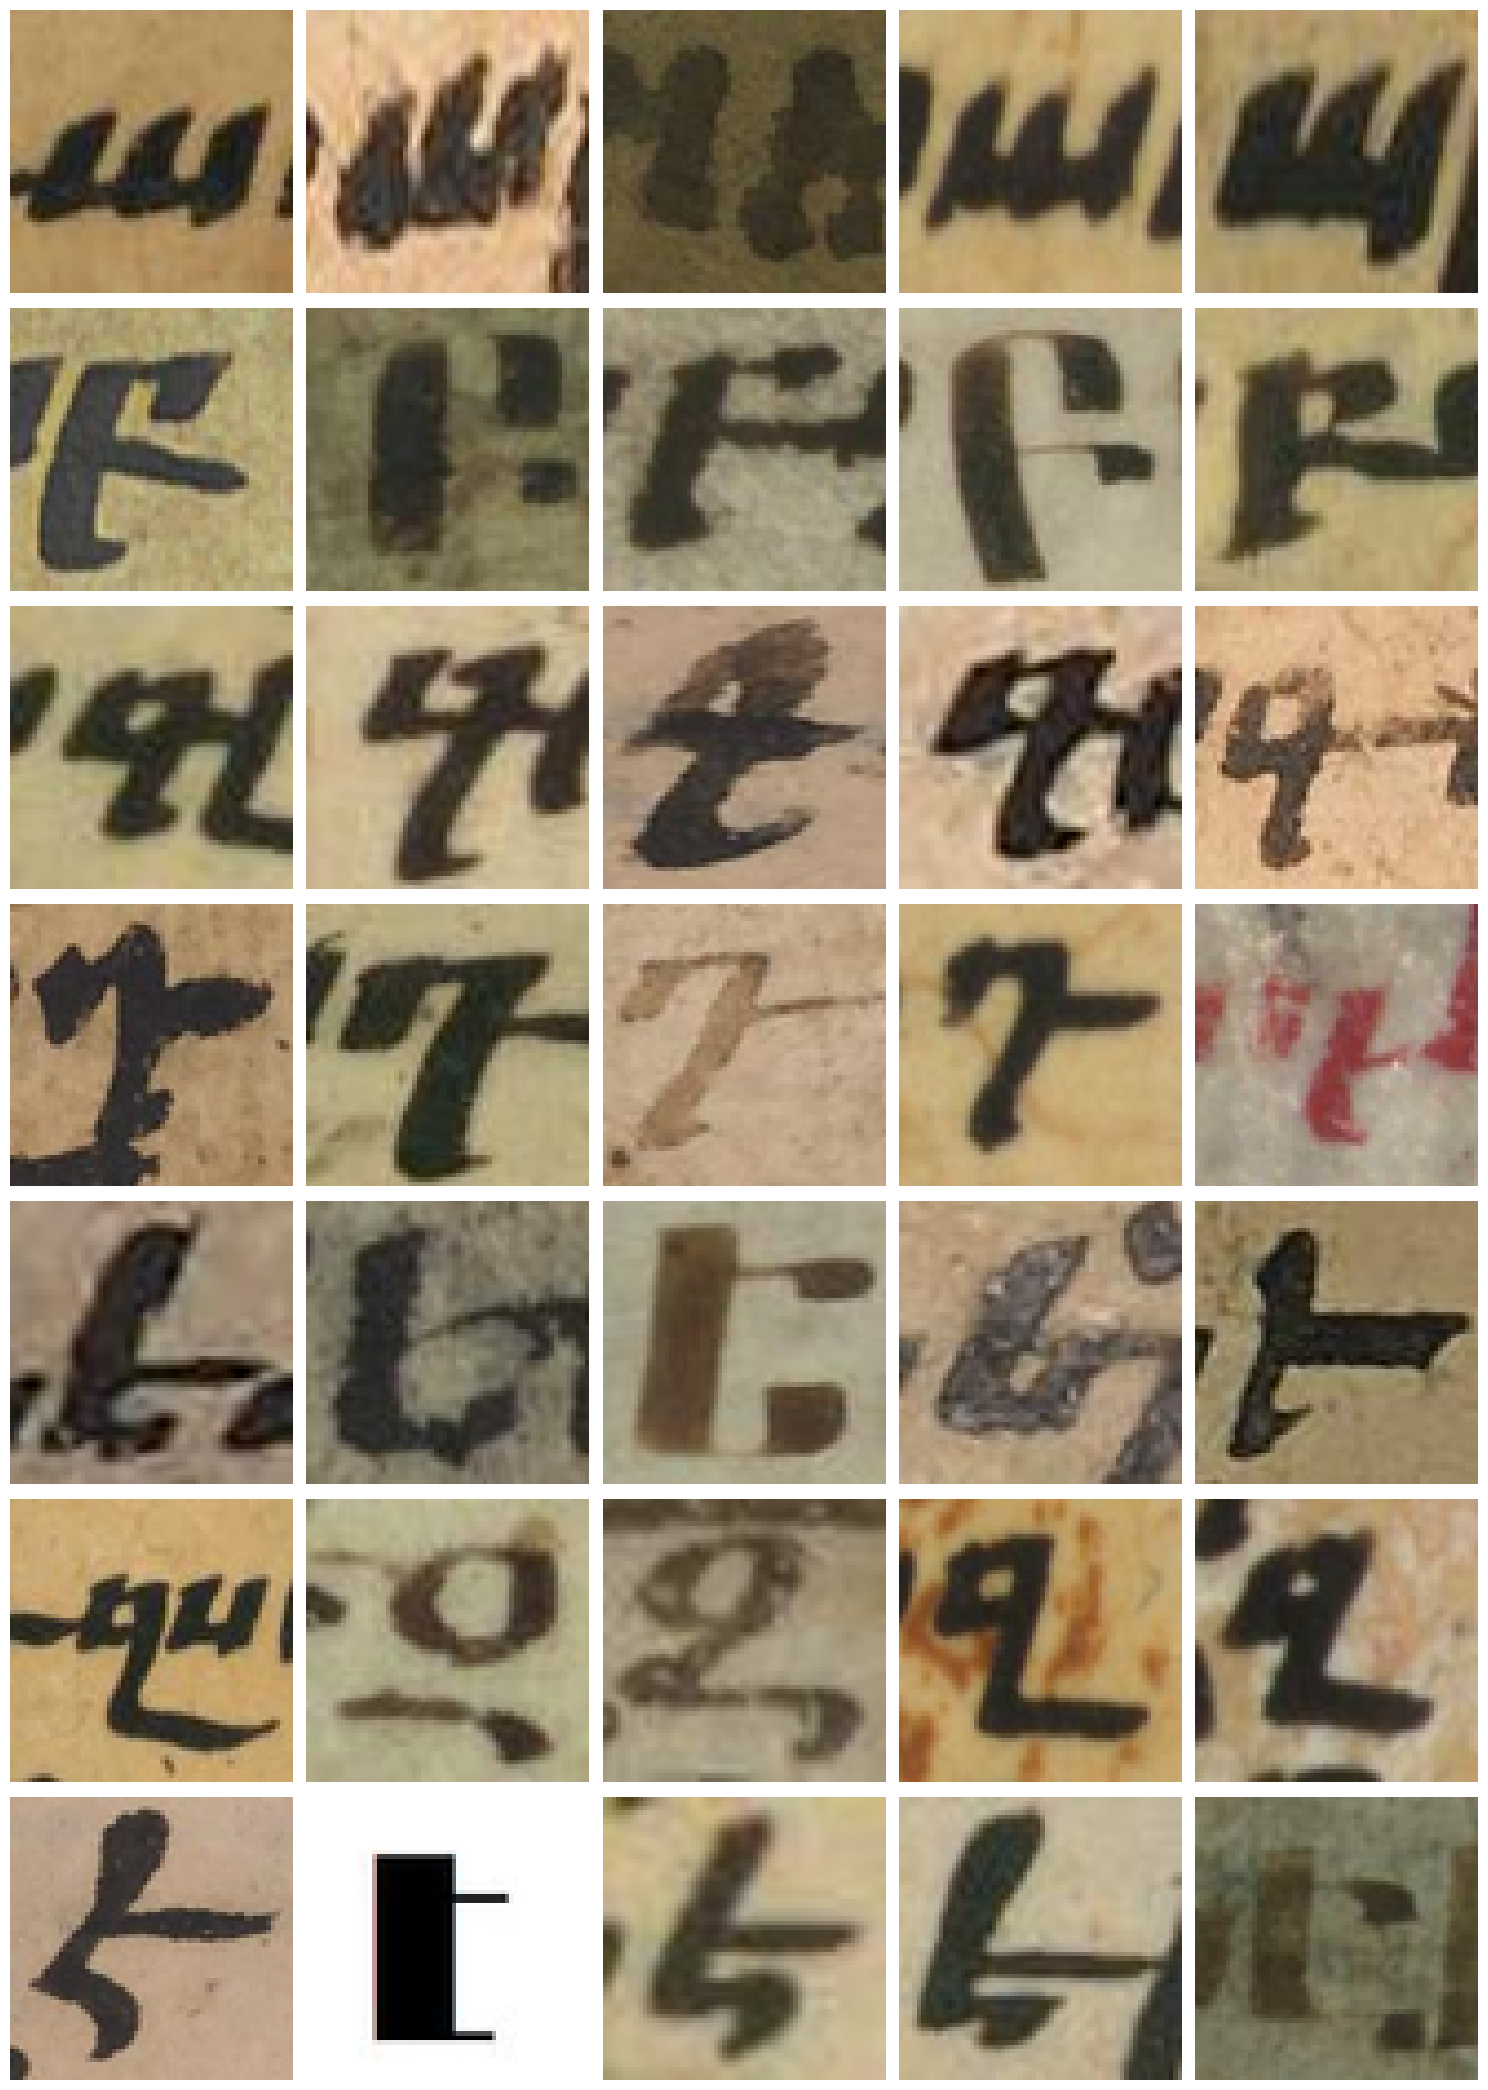

In [88]:

n_classes = len(class_names)
samples_per_class = 5

fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(15, 3*n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, class_name in enumerate(class_names):
    class_indices = np.where(labels == class_name)[0]
    
    sample_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)
    
    for j, idx in enumerate(sample_indices):
        axes[i, j].imshow(images[idx])
        if j == 0:
            axes[i, j].set_ylabel(f'Classe {class_name}', fontsize=12, fontweight='bold')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

### Extraction des features

In [89]:
features_all = extract_features_from_images(
    images, 
    feature_types=['hog', 'lbp', 'hu', 'geometric']
)

print(f"Features extraites: {features_all.shape}")

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_all)

Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
Features extraites: (364, 619)


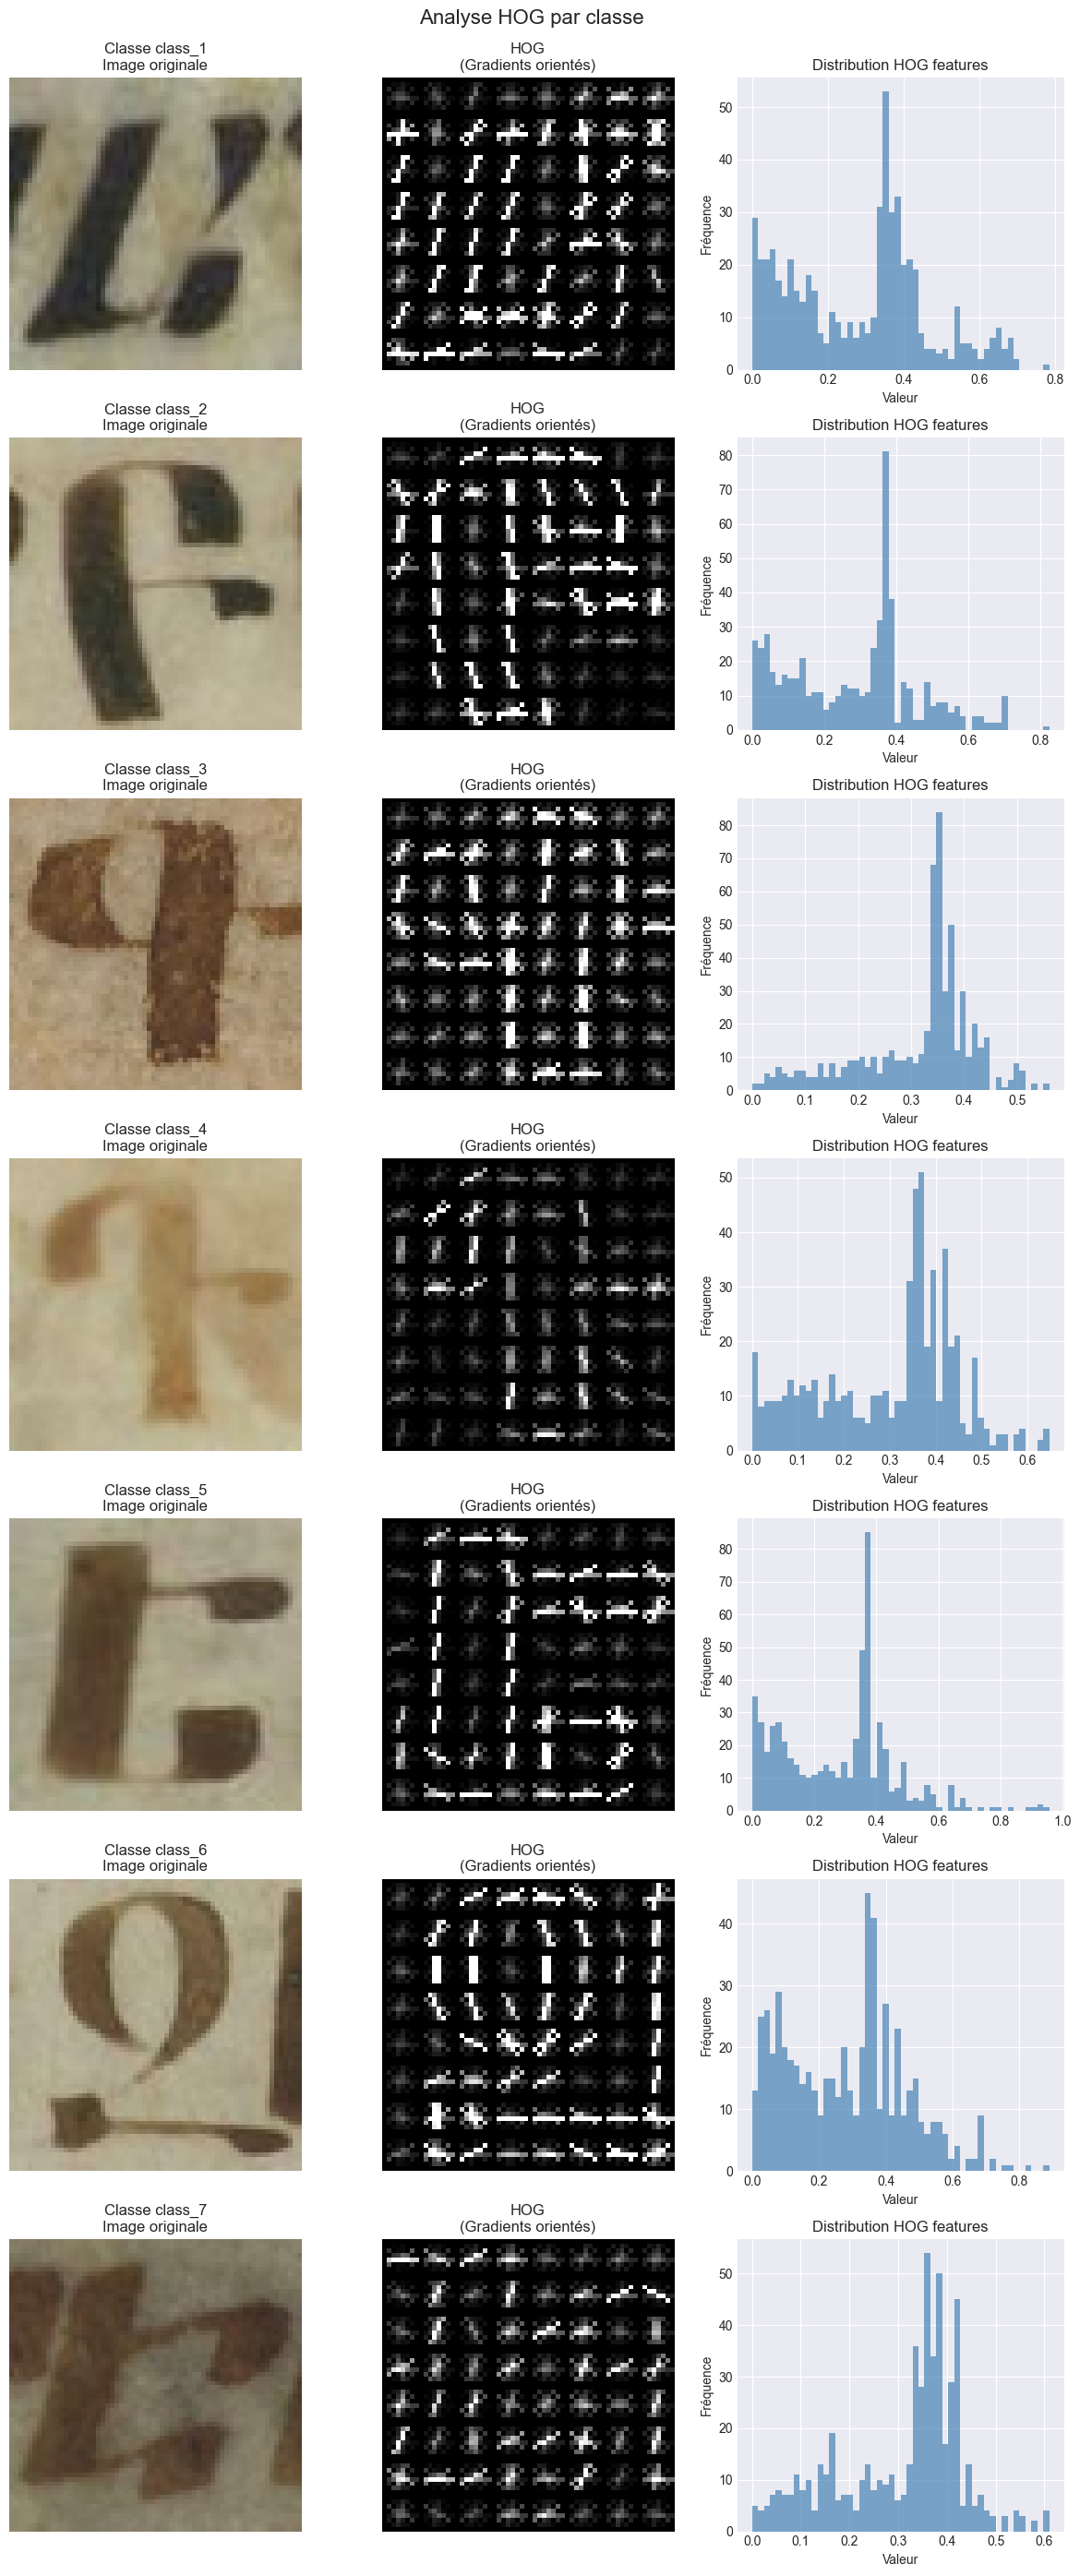

In [90]:
fig, axes = plt.subplots(n_classes, 3, figsize=(12, 4*n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, class_name in enumerate(class_names):
    # Prendre un exemple représentatif
    class_indices = np.where(labels == class_name)[0]
    sample_idx = class_indices[0]
    sample_img = images[sample_idx]
    
    # Extraire HOG
    hog_features, hog_image = extract_hog_features(sample_img)
    
    # Image originale
    axes[i, 0].imshow(sample_img)
    axes[i, 0].set_title(f'Classe {class_name}\nImage originale')
    axes[i, 0].axis('off')
    
    # HOG visualization
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    axes[i, 1].imshow(hog_image_rescaled, cmap='gray')
    axes[i, 1].set_title('HOG\n(Gradients orientés)')
    axes[i, 1].axis('off')
    
    # Histogramme des features HOG
    axes[i, 2].hist(hog_features, bins=50, alpha=0.7, color='steelblue')
    axes[i, 2].set_title('Distribution HOG features')
    axes[i, 2].set_xlabel('Valeur')
    axes[i, 2].set_ylabel('Fréquence')

plt.suptitle('Analyse HOG par classe', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

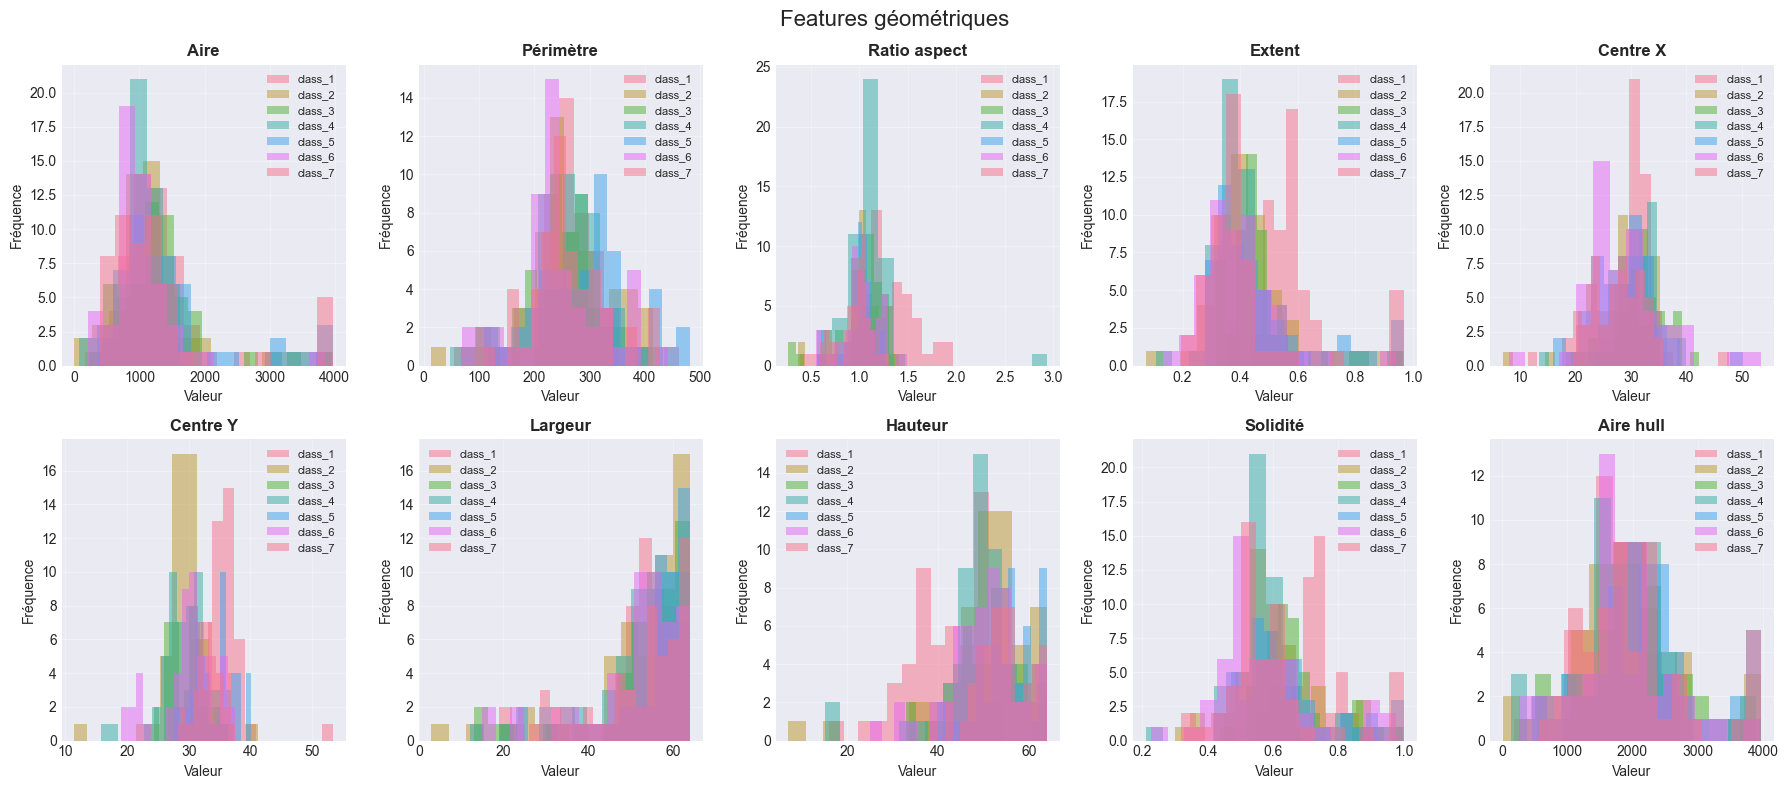


Moyennes des features géométriques par classe:

Classe class_1:
  Aire           :  1273.62
  Périmètre      :   257.16
  Ratio aspect   :     1.29
  Extent         :     0.56
  Centre X       :    30.63
  Centre Y       :    34.89
  Largeur        :    52.73
  Hauteur        :    42.19
  Solidité       :     0.72
  Aire hull      :  1776.16

Classe class_2:
  Aire           :  1238.11
  Périmètre      :   261.79
  Ratio aspect   :     1.02
  Extent         :     0.44
  Centre X       :    27.80
  Centre Y       :    29.34
  Largeur        :    51.75
  Hauteur        :    50.38
  Solidité       :     0.62
  Aire hull      :  1925.65

Classe class_3:
  Aire           :  1259.64
  Périmètre      :   250.73
  Ratio aspect   :     1.02
  Extent         :     0.46
  Centre X       :    31.44
  Centre Y       :    29.37
  Largeur        :    52.54
  Hauteur        :    51.31
  Solidité       :     0.65
  Aire hull      :  1965.36

Classe class_4:
  Aire           :  1105.09
  Périmètre     

In [91]:
# Analyse des features géométriques par classe

# Extraire uniquement les features géométriques
geometric_features_list = []
for img in images:
    geom_feat = extract_geometric_features(img)
    geometric_features_list.append(geom_feat)

geometric_features = np.array(geometric_features_list)

geom_names = ['Aire', 'Périmètre', 'Ratio aspect', 'Extent', 
              'Centre X', 'Centre Y', 'Largeur', 'Hauteur', 'Solidité', 'Aire hull']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for feat_idx, feat_name in enumerate(geom_names):
    ax = axes[feat_idx]
    
    for class_name in class_names:
        class_mask = labels == class_name
        values = geometric_features[class_mask, feat_idx]
        ax.hist(values, alpha=0.5, label=class_name, bins=15)
    
    ax.set_title(feat_name, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Features géométriques', fontsize=16)
plt.tight_layout()
plt.show()

# Moyennes par classe
print("\nMoyennes des features géométriques par classe:")
print("=" * 80)
for class_name in class_names:
    class_mask = labels == class_name
    means = geometric_features[class_mask].mean(axis=0)
    print(f"\nClasse {class_name}:")
    for feat_name, mean_val in zip(geom_names, means):
        print(f"  {feat_name:15s}: {mean_val:8.2f}")

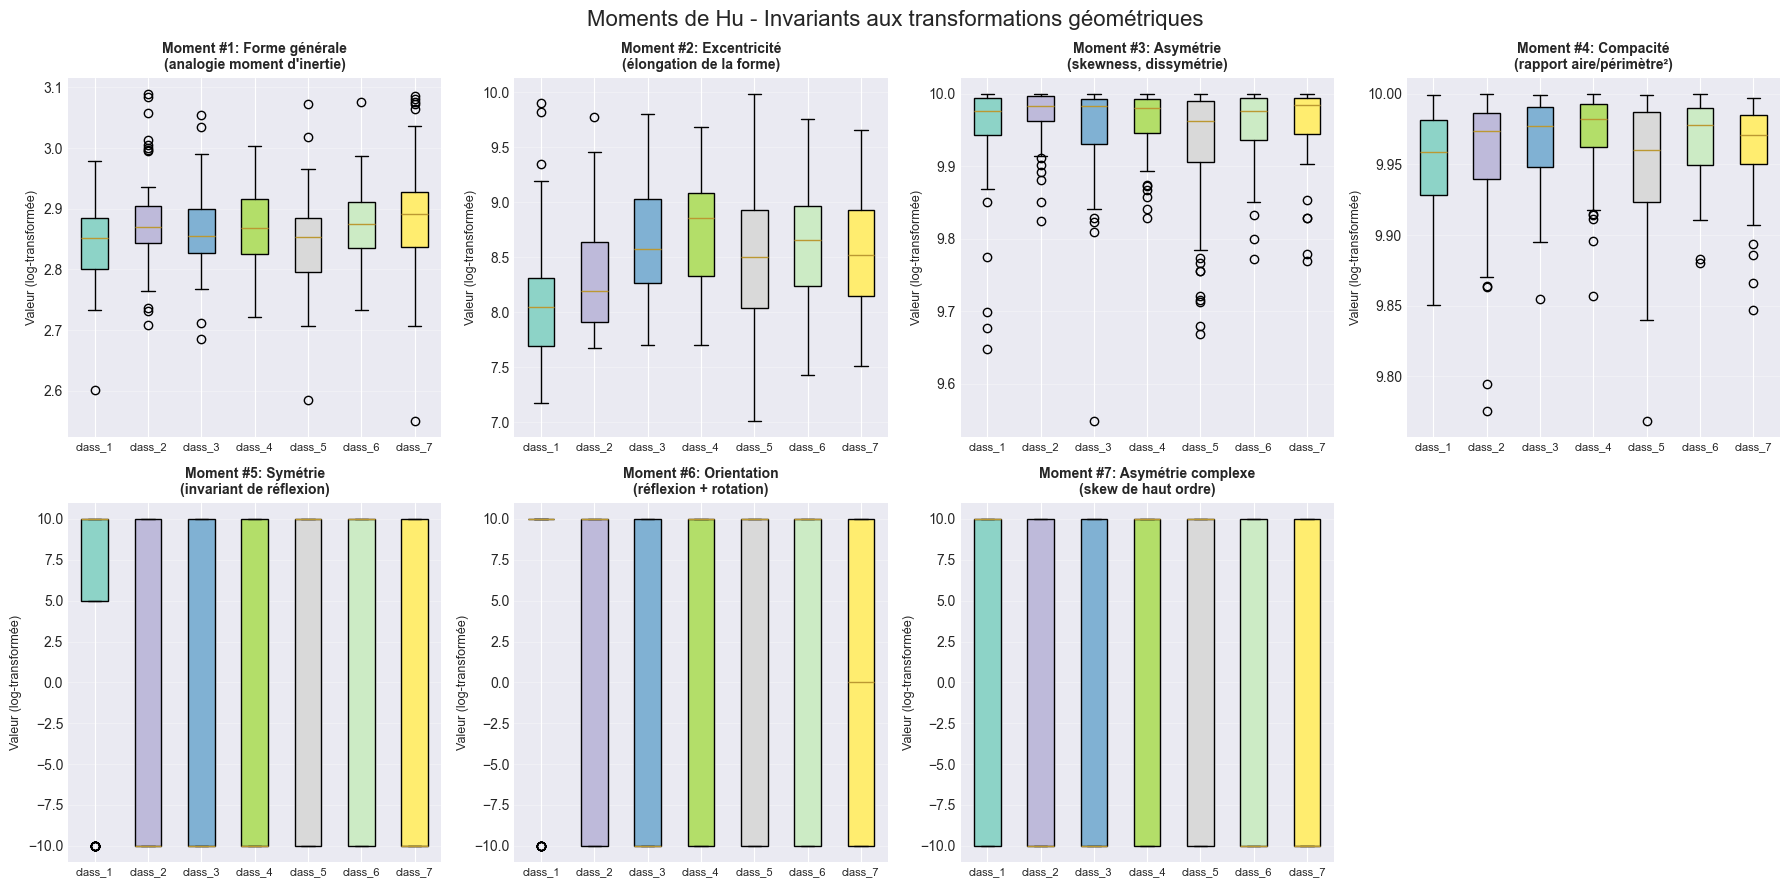


Variabilité des moments de Hu entre classes:
Moment #1 (Forme générale): variance = 0.0003
Moment #2 (Excentricité): variance = 0.0451
Moment #3 (Asymétrie): variance = 0.0002
Moment #4 (Compacité): variance = 0.0001
Moment #5 (Symétrie): variance = 6.4847
Moment #6 (Orientation): variance = 9.6969
Moment #7 (Asymétrie complexe): variance = 1.7933


In [92]:
# Analyse des moments de Hu par classe

# Extraire les moments de Hu
hu_features_list = []
for img in images:
    hu_feat = extract_hu_moments(img)
    hu_features_list.append(hu_feat)

hu_features = np.array(hu_features_list)

# Descriptions des moments de Hu
hu_descriptions = [
    "Moment #1: Forme générale\n(analogie moment d'inertie)",
    "Moment #2: Excentricité\n(élongation de la forme)",
    "Moment #3: Asymétrie\n(skewness, dissymétrie)",
    "Moment #4: Compacité\n(rapport aire/périmètre²)",
    "Moment #5: Symétrie\n(invariant de réflexion)",
    "Moment #6: Orientation\n(réflexion + rotation)",
    "Moment #7: Asymétrie complexe\n(skew de haut ordre)"
]

# Visualiser les 7 moments de Hu par classe
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for i in range(7):
    ax = axes[i]
    
    # Box plot par classe
    data_by_class = [hu_features[labels == cn, i] for cn in class_names]
    bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
    
    # Colorier
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(hu_descriptions[i], fontweight='bold', fontsize=10)
    ax.set_ylabel('Valeur (log-transformée)', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=0, labelsize=8)

axes[7].axis('off')

plt.suptitle('Moments de Hu - Invariants aux transformations géométriques', fontsize=16)
plt.tight_layout()
plt.show()

# Identifier les moments les plus discriminants
print("\nVariabilité des moments de Hu entre classes:")
for i in range(7):
    class_means = [hu_features[labels == cn, i].mean() for cn in class_names]
    variance = np.var(class_means)
    desc_short = hu_descriptions[i].split('\n')[0].replace('Moment #' + str(i+1) + ': ', '')
    print(f"Moment #{i+1} ({desc_short}): variance = {variance:.4f}")

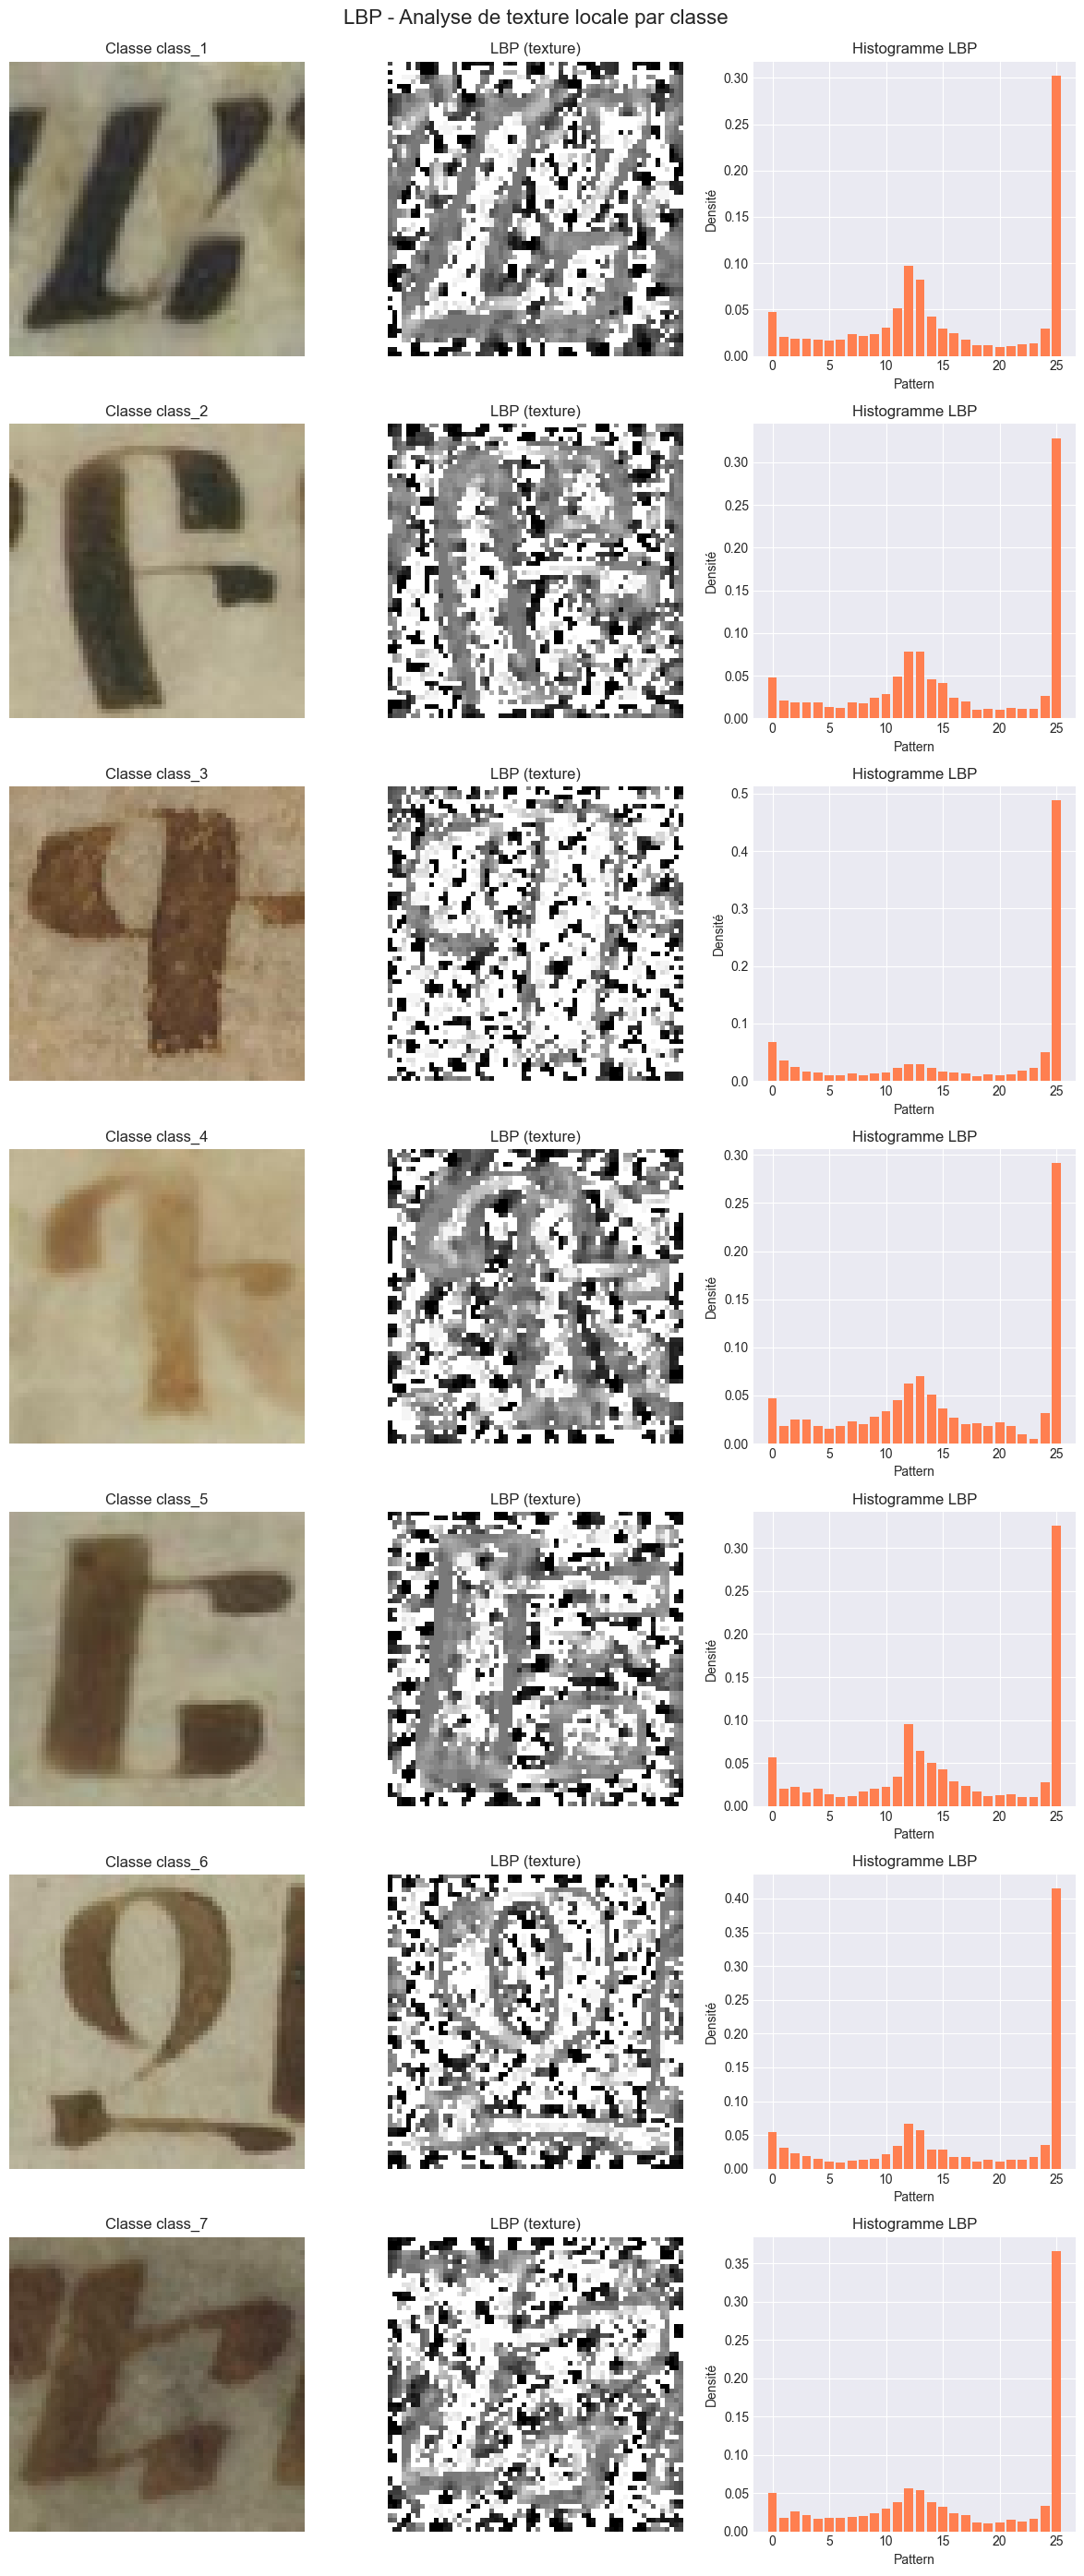


Interprétation LBP:
  - Chaque pattern représente une configuration locale de pixels
  - Les pics indiquent les textures dominantes du caractère
  - Les différences entre classes révèlent les variations de texture


In [93]:
# Analyse LBP : texture locale

# Extraire LBP et visualiser
fig, axes = plt.subplots(n_classes, 3, figsize=(12, 4*n_classes))
if n_classes == 1:
    axes = axes.reshape(1, -1)

for i, class_name in enumerate(class_names):
    class_indices = np.where(labels == class_name)[0]
    sample_idx = class_indices[0]
    sample_img = images[sample_idx]
    
    # Convertir en niveaux de gris
    if len(sample_img.shape) == 3:
        gray = cv2.cvtColor(sample_img, cv2.COLOR_RGB2GRAY)
    else:
        gray = sample_img
    
    # Calculer LBP
    lbp = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_hist = extract_lbp_features(sample_img)
    
    # Image originale
    axes[i, 0].imshow(sample_img)
    axes[i, 0].set_title(f'Classe {class_name}')
    axes[i, 0].axis('off')
    
    # LBP image
    axes[i, 1].imshow(lbp, cmap='gray')
    axes[i, 1].set_title('LBP (texture)')
    axes[i, 1].axis('off')
    
    # Histogramme LBP
    axes[i, 2].bar(range(len(lbp_hist)), lbp_hist, color='coral')
    axes[i, 2].set_title('Histogramme LBP')
    axes[i, 2].set_xlabel('Pattern')
    axes[i, 2].set_ylabel('Densité')

plt.suptitle('LBP - Analyse de texture locale par classe', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\nInterprétation LBP:")
print("  - Chaque pattern représente une configuration locale de pixels")
print("  - Les pics indiquent les textures dominantes du caractère")
print("  - Les différences entre classes révèlent les variations de texture")

Analyse PCA:
  Variance expliquée PC1: 9.16%
  Variance expliquée PC2: 4.42%
  Total variance expliquée: 13.58%


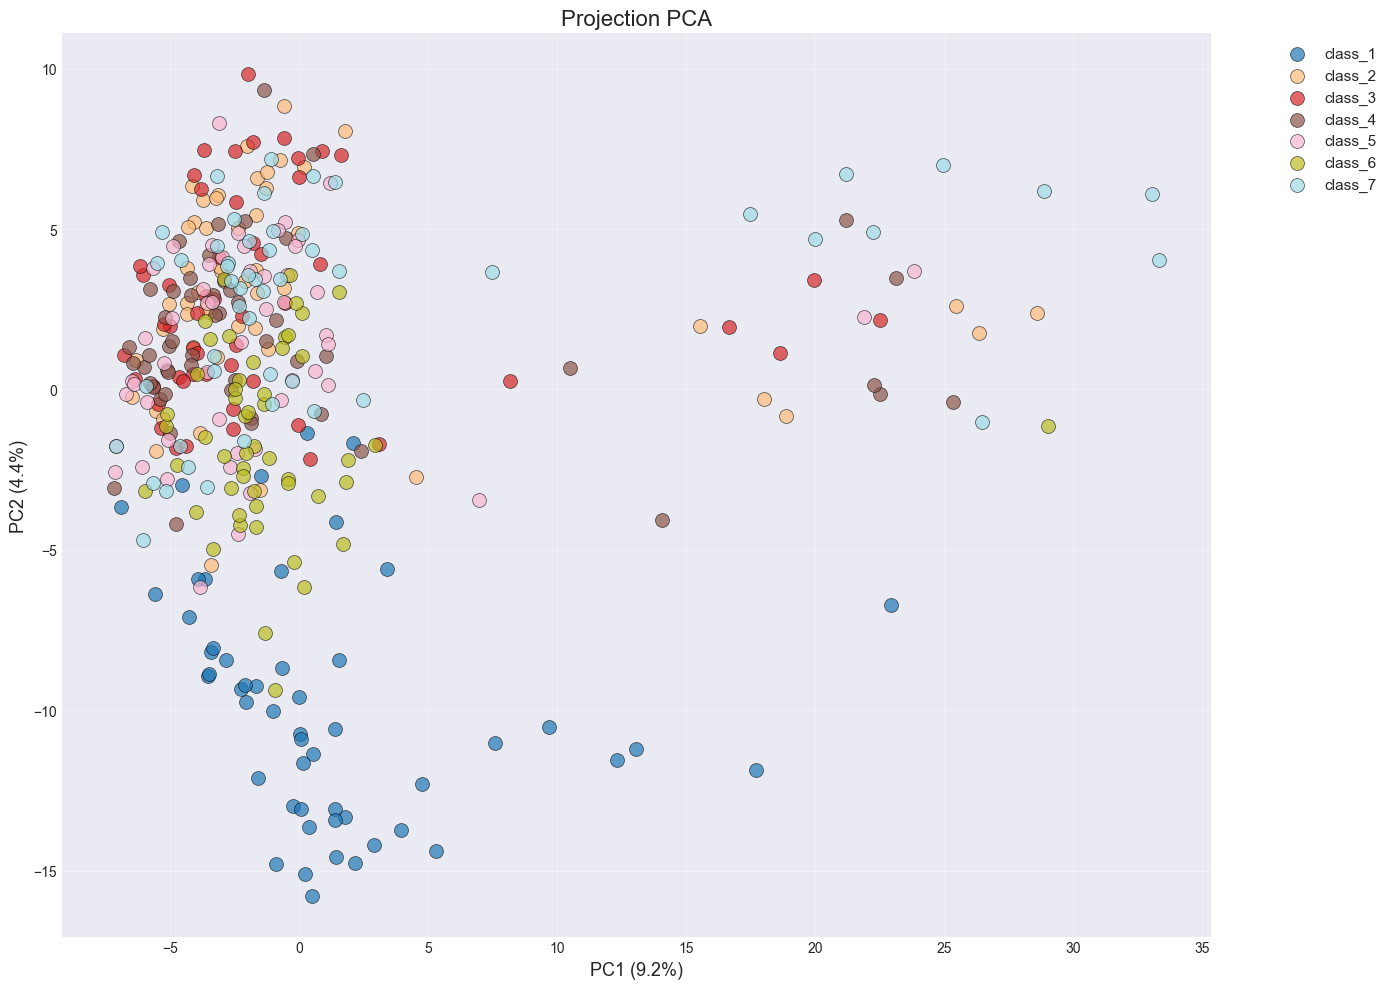


Interprétation:
  Séparation limitée : beaucoup d'information dans les dimensions supérieures


In [94]:
# PCA : Réduction de dimensionalité et visualisation

# Encoder les labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# PCA à 2 dimensions
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

print(f"Analyse PCA:")
print(f"  Variance expliquée PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  Variance expliquée PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total variance expliquée: {pca.explained_variance_ratio_.sum():.2%}")

# Visualisation
plt.figure(figsize=(14, 10))

colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))

for i, class_name in enumerate(class_names):
    mask = labels == class_name
    plt.scatter(
        features_pca[mask, 0], 
        features_pca[mask, 1],
        c=[colors[i]], 
        label=f'{class_name}',
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=13)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=13)
plt.title('Projection PCA', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterprétation:")
if pca.explained_variance_ratio_.sum() > 0.70:
    print("  Bonne séparation : les 2 premières composantes capturent >70% de la variance")
else:
    print("  Séparation limitée : beaucoup d'information dans les dimensions supérieures")

Calcul de t-SNE (peut prendre 30-60 secondes)...


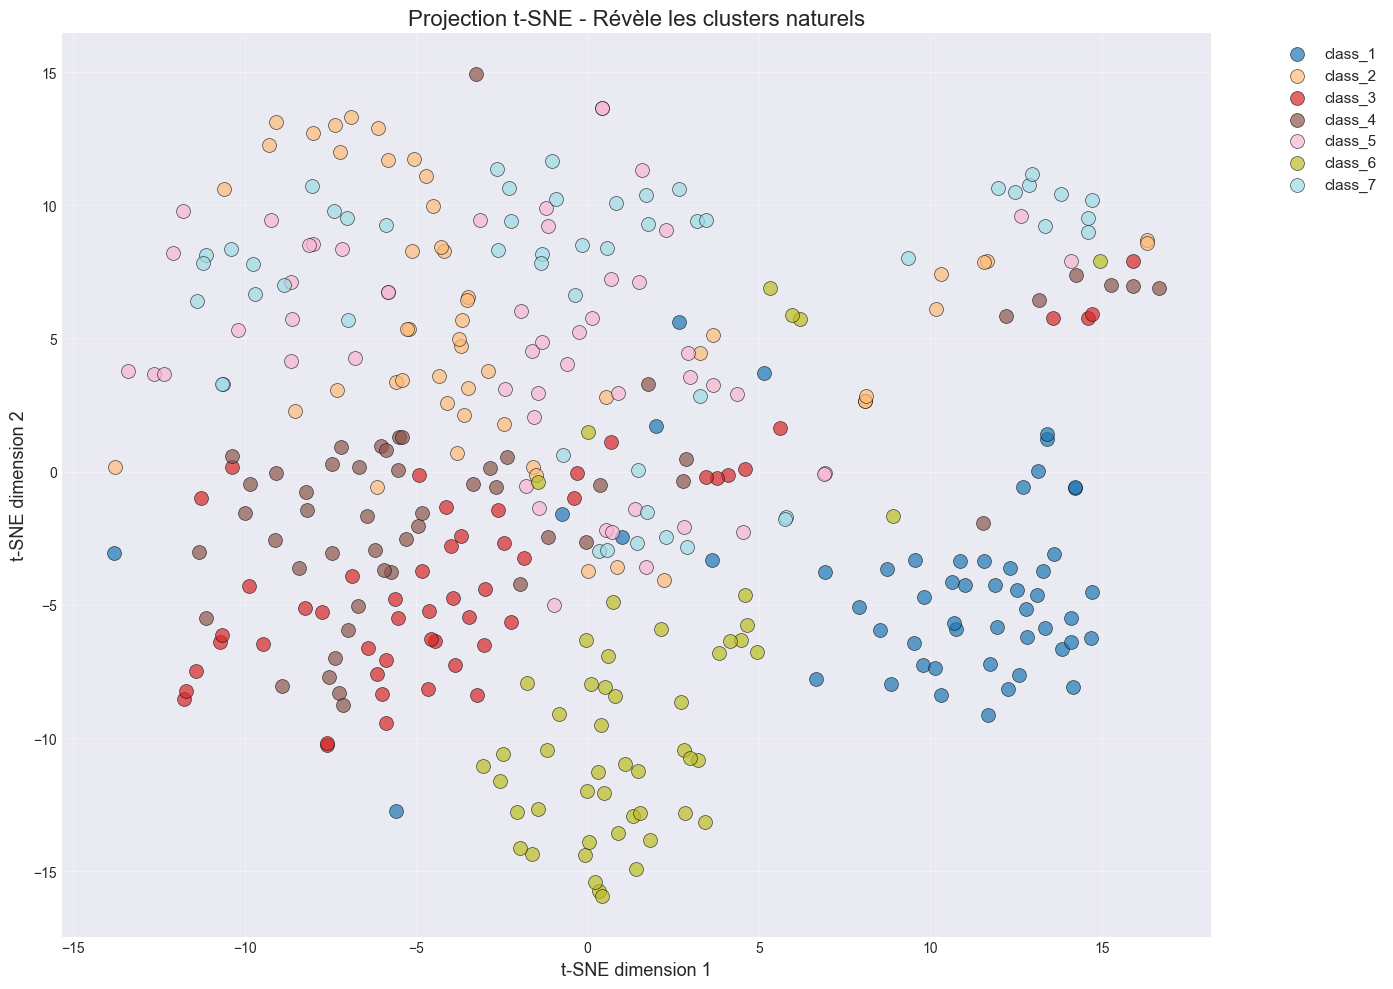


Interprétation t-SNE:
  - Préserve les distances locales (voisinages)
  - Les clusters visibles indiquent des similarités réelles
  - La séparation suggère que les features sont discriminantes


In [95]:
# t-SNE : Visualisation non-linéaire

print("Calcul de t-SNE (peut prendre 30-60 secondes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(images)//4))
features_tsne = tsne.fit_transform(features_scaled)

plt.figure(figsize=(14, 10))

for i, class_name in enumerate(class_names):
    mask = labels == class_name
    plt.scatter(
        features_tsne[mask, 0], 
        features_tsne[mask, 1],
        c=[colors[i]], 
        label=f'{class_name}',
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel('t-SNE dimension 1', fontsize=13)
plt.ylabel('t-SNE dimension 2', fontsize=13)
plt.title('Projection t-SNE - Révèle les clusters naturels', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterprétation t-SNE:")
print("  - Préserve les distances locales (voisinages)")
print("  - Les clusters visibles indiquent des similarités réelles")
print("  - La séparation suggère que les features sont discriminantes")

In [96]:
# Classification KNN avec validation croisée

X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, labels_encoded, 
    test_size=0.25, random_state=42, stratify=labels_encoded
)

print(f"Entraînement: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"\nTest de différentes valeurs de k:")
print("=" * 60)

k_values = [1, 3, 5, 7, 10]
best_k = 5
best_acc = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    # Validation croisée sur le train set
    cv_scores = cross_val_score(knn, X_train, y_train, cv=min(5, len(np.unique(y_train))))
    
    # Test sur test set
    knn.fit(X_train, y_train)
    test_acc = knn.score(X_test, y_test)
    
    print(f"k={k:2d} | CV: {cv_scores.mean():.3f} ±{cv_scores.std():.3f} | Test: {test_acc:.3f}")
    
    if test_acc > best_acc:
        best_acc = test_acc
        best_k = k

print(f"\nMeilleur k: {best_k} (précision test: {best_acc:.2%})")

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

print(f"\nPerformance finale:")
print(f"  Précision: {accuracy_score(y_test, y_pred):.2%}")

Entraînement: 273 | Test: 91

Test de différentes valeurs de k:
k= 1 | CV: 0.579 ±0.071 | Test: 0.670
k= 3 | CV: 0.593 ±0.039 | Test: 0.615
k= 5 | CV: 0.593 ±0.028 | Test: 0.659
k= 7 | CV: 0.590 ±0.019 | Test: 0.703
k=10 | CV: 0.612 ±0.047 | Test: 0.692

Meilleur k: 7 (précision test: 70.33%)

Performance finale:
  Précision: 70.33%


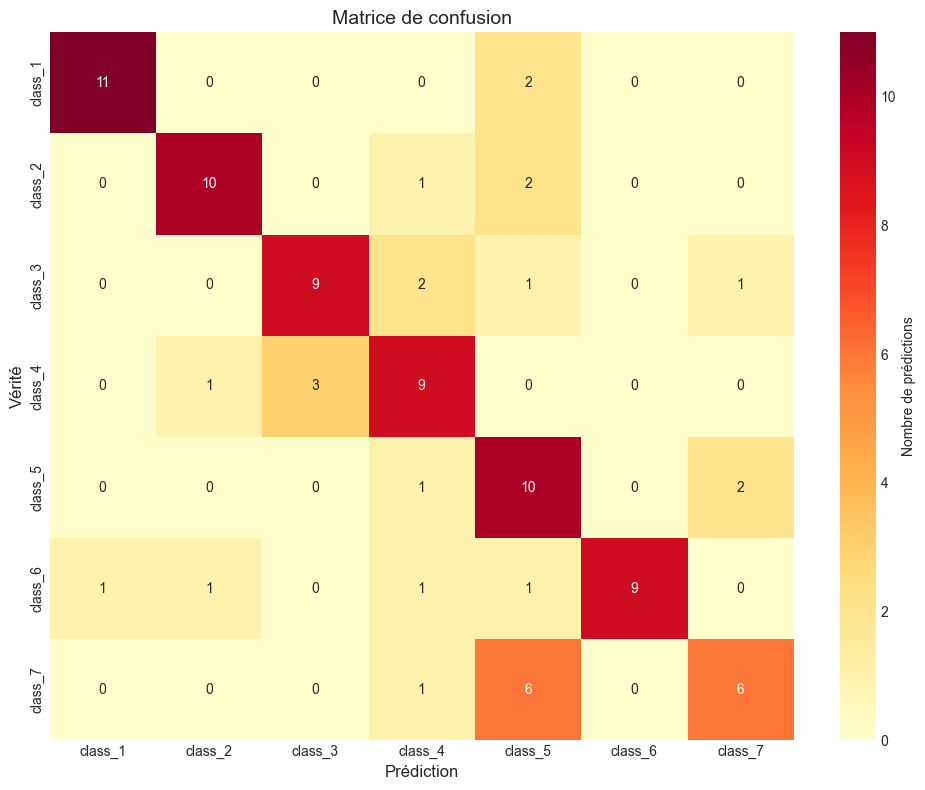


Rapport de classification:
              precision    recall  f1-score   support

     class_1      0.917     0.846     0.880        13
     class_2      0.833     0.769     0.800        13
     class_3      0.750     0.692     0.720        13
     class_4      0.600     0.692     0.643        13
     class_5      0.455     0.769     0.571        13
     class_6      1.000     0.692     0.818        13
     class_7      0.667     0.462     0.545        13

    accuracy                          0.703        91
   macro avg      0.746     0.703     0.711        91
weighted avg      0.746     0.703     0.711        91


Analyse des confusions principales:
  class_1 → class_5: 2 erreurs (15.4%)
  class_2 → class_4: 1 erreurs (7.7%)
  class_2 → class_5: 2 erreurs (15.4%)
  class_3 → class_4: 2 erreurs (15.4%)
  class_3 → class_5: 1 erreurs (7.7%)
  class_3 → class_7: 1 erreurs (7.7%)
  class_4 → class_2: 1 erreurs (7.7%)
  class_4 → class_3: 3 erreurs (23.1%)
  class_5 → class_4: 1 erreurs

In [97]:
# Matrice de confusion détaillée

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de prédictions'})
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité', fontsize=12)
plt.title('Matrice de confusion', fontsize=14)
plt.tight_layout()
plt.show()

print("\nRapport de classification:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

print("\nAnalyse des confusions principales:")
for i, true_class in enumerate(le.classes_):
    for j, pred_class in enumerate(le.classes_):
        if i != j and cm[i, j] > 0:
            print(f"  {true_class} → {pred_class}: {cm[i, j]} erreurs ({cm[i, j]/cm[i].sum()*100:.1f}%)")

Analyse de l'importance des features

Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
HOG             | Features:  576 | Précision: 0.615
Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
LBP             | Features:   26 | Précision: 0.209
Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
Hu Moments      | Features:    7 | Précision: 0.264
Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
Géométrique     | Features:   10 | Précision: 0.418
Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/364
  350/364
HOG+LBP         | Features:  602 | Précision: 0.615
Extraction de features pour 364 images...
  0/364
  50/364
  100/364
  150/364
  200/364
  250/364
  300/36

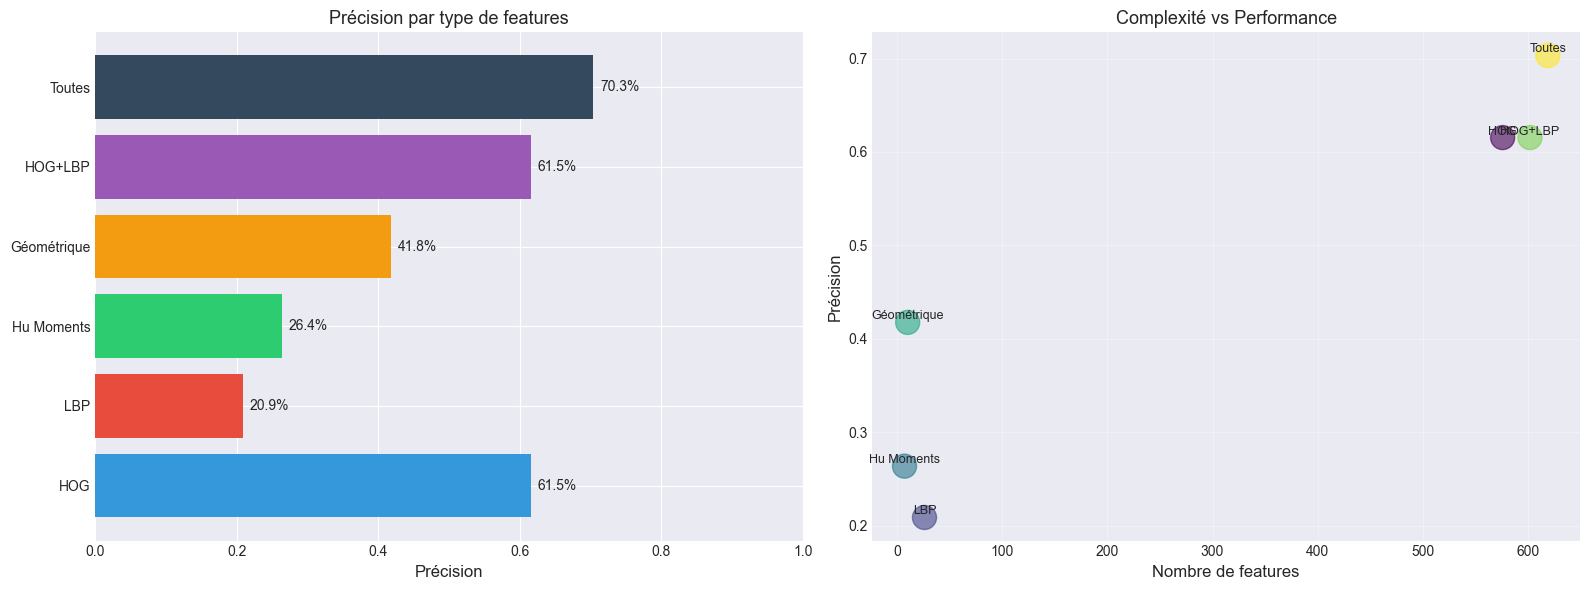


Meilleur type de features: Toutes
   Précision: 70.33%
   Nombre de features: 619


In [98]:
# Analyse de l'importance des features

print("Analyse de l'importance des features\n")

# Extraire séparément chaque type de feature
feature_types_analysis = {
    'HOG': ['hog'],
    'LBP': ['lbp'],
    'Hu Moments': ['hu'],
    'Géométrique': ['geometric'],
    'HOG+LBP': ['hog', 'lbp'],
    'Toutes': ['hog', 'lbp', 'hu', 'geometric']
}

results = {}

for name, ftypes in feature_types_analysis.items():
    # Extraire les features
    feat_temp = extract_features_from_images(images, ftypes)
    feat_scaled = StandardScaler().fit_transform(feat_temp)
    
    # Train/test split
    X_tr, X_te, y_tr, y_te = train_test_split(
        feat_scaled, labels_encoded, 
        test_size=0.25, random_state=42, stratify=labels_encoded
    )
    
    # KNN
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_tr, y_tr)
    acc = knn.score(X_te, y_te)
    
    results[name] = {
        'accuracy': acc,
        'n_features': feat_temp.shape[1]
    }
    
    print(f"{name:15s} | Features: {feat_temp.shape[1]:4d} | Précision: {acc:.3f}")

print("\n" + "=" * 60)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Précision par type
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors_bar = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#34495e']

bars = ax1.barh(names, accs, color=colors_bar)
ax1.set_xlabel('Précision', fontsize=12)
ax1.set_title('Précision par type de features', fontsize=13)
ax1.set_xlim([0, 1])
for i, (name, acc) in enumerate(zip(names, accs)):
    ax1.text(acc + 0.01, i, f'{acc:.1%}', va='center', fontsize=10)

# Plot 2: Complexité vs Performance
n_feats = [results[n]['n_features'] for n in names]
ax2.scatter(n_feats, accs, s=300, alpha=0.6, c=range(len(names)), cmap='viridis')
for i, name in enumerate(names):
    ax2.annotate(name, (n_feats[i], accs[i]), 
                fontsize=9, ha='center', va='bottom')
ax2.set_xlabel('Nombre de features', fontsize=12)
ax2.set_ylabel('Précision', fontsize=12)
ax2.set_title('Complexité vs Performance', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusion
best_type = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nMeilleur type de features: {best_type}")
print(f"   Précision: {results[best_type]['accuracy']:.2%}")
print(f"   Nombre de features: {results[best_type]['n_features']}")

Création des profils de features par classe



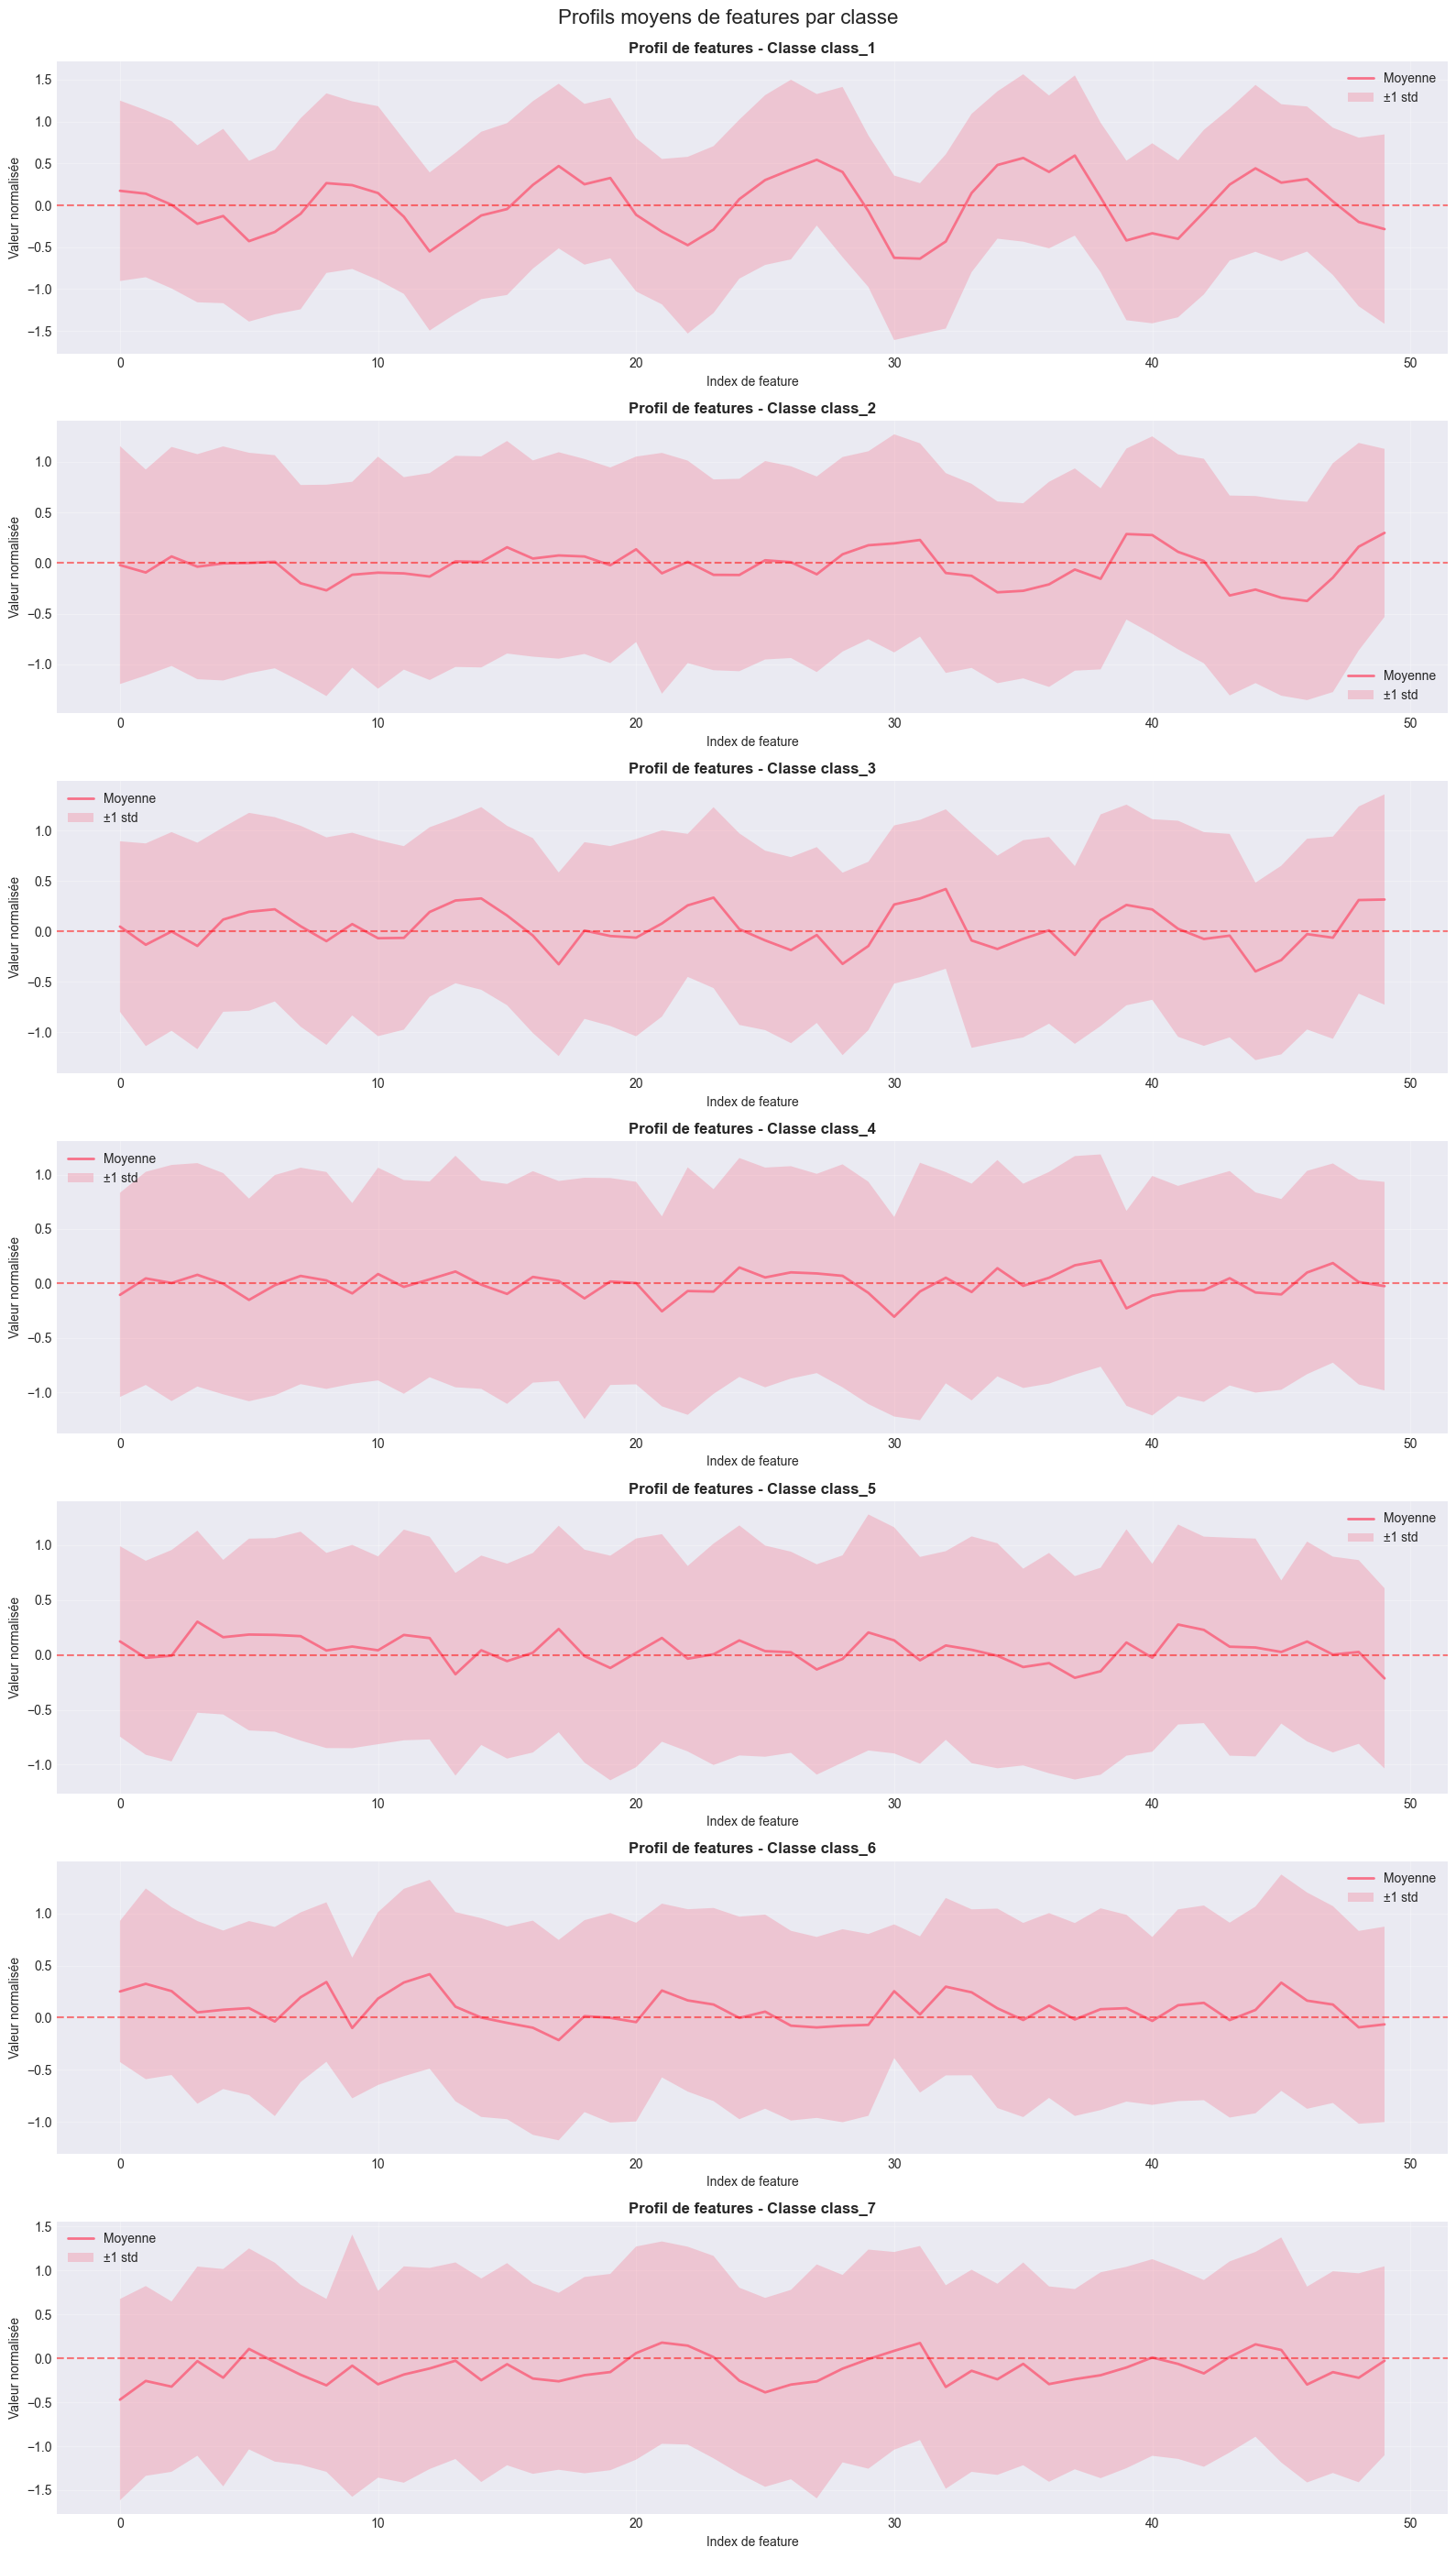


Interprétation:
  - Chaque courbe représente le 'profil type' d'une classe
  - Les pics indiquent les features dominantes pour cette classe
  - Les différences entre profils expliquent la séparabilité des classes


In [99]:
# Profils moyens de features par classe

print("Création des profils de features par classe\n")

# Calculer les features moyennes par classe
class_profiles = {}

for class_name in class_names:
    mask = labels == class_name
    class_features = features_scaled[mask]
    class_profiles[class_name] = {
        'mean': class_features.mean(axis=0),
        'std': class_features.std(axis=0)
    }

# Visualiser les profils (premières 50 features)
fig, axes = plt.subplots(n_classes, 1, figsize=(16, 4*n_classes))
if n_classes == 1:
    axes = [axes]

for i, class_name in enumerate(class_names):
    mean_profile = class_profiles[class_name]['mean'][:50]
    std_profile = class_profiles[class_name]['std'][:50]
    
    x = np.arange(len(mean_profile))
    axes[i].plot(x, mean_profile, linewidth=2, label='Moyenne')
    axes[i].fill_between(x, 
                          mean_profile - std_profile, 
                          mean_profile + std_profile,
                          alpha=0.3, label='±1 std')
    axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Profil de features - Classe {class_name}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Index de feature')
    axes[i].set_ylabel('Valeur normalisée')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Profils moyens de features par classe', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\nInterprétation:")
print("  - Chaque courbe représente le 'profil type' d'une classe")
print("  - Les pics indiquent les features dominantes pour cette classe")
print("  - Les différences entre profils expliquent la séparabilité des classes")

Superposition des profils de classes pour comparaison



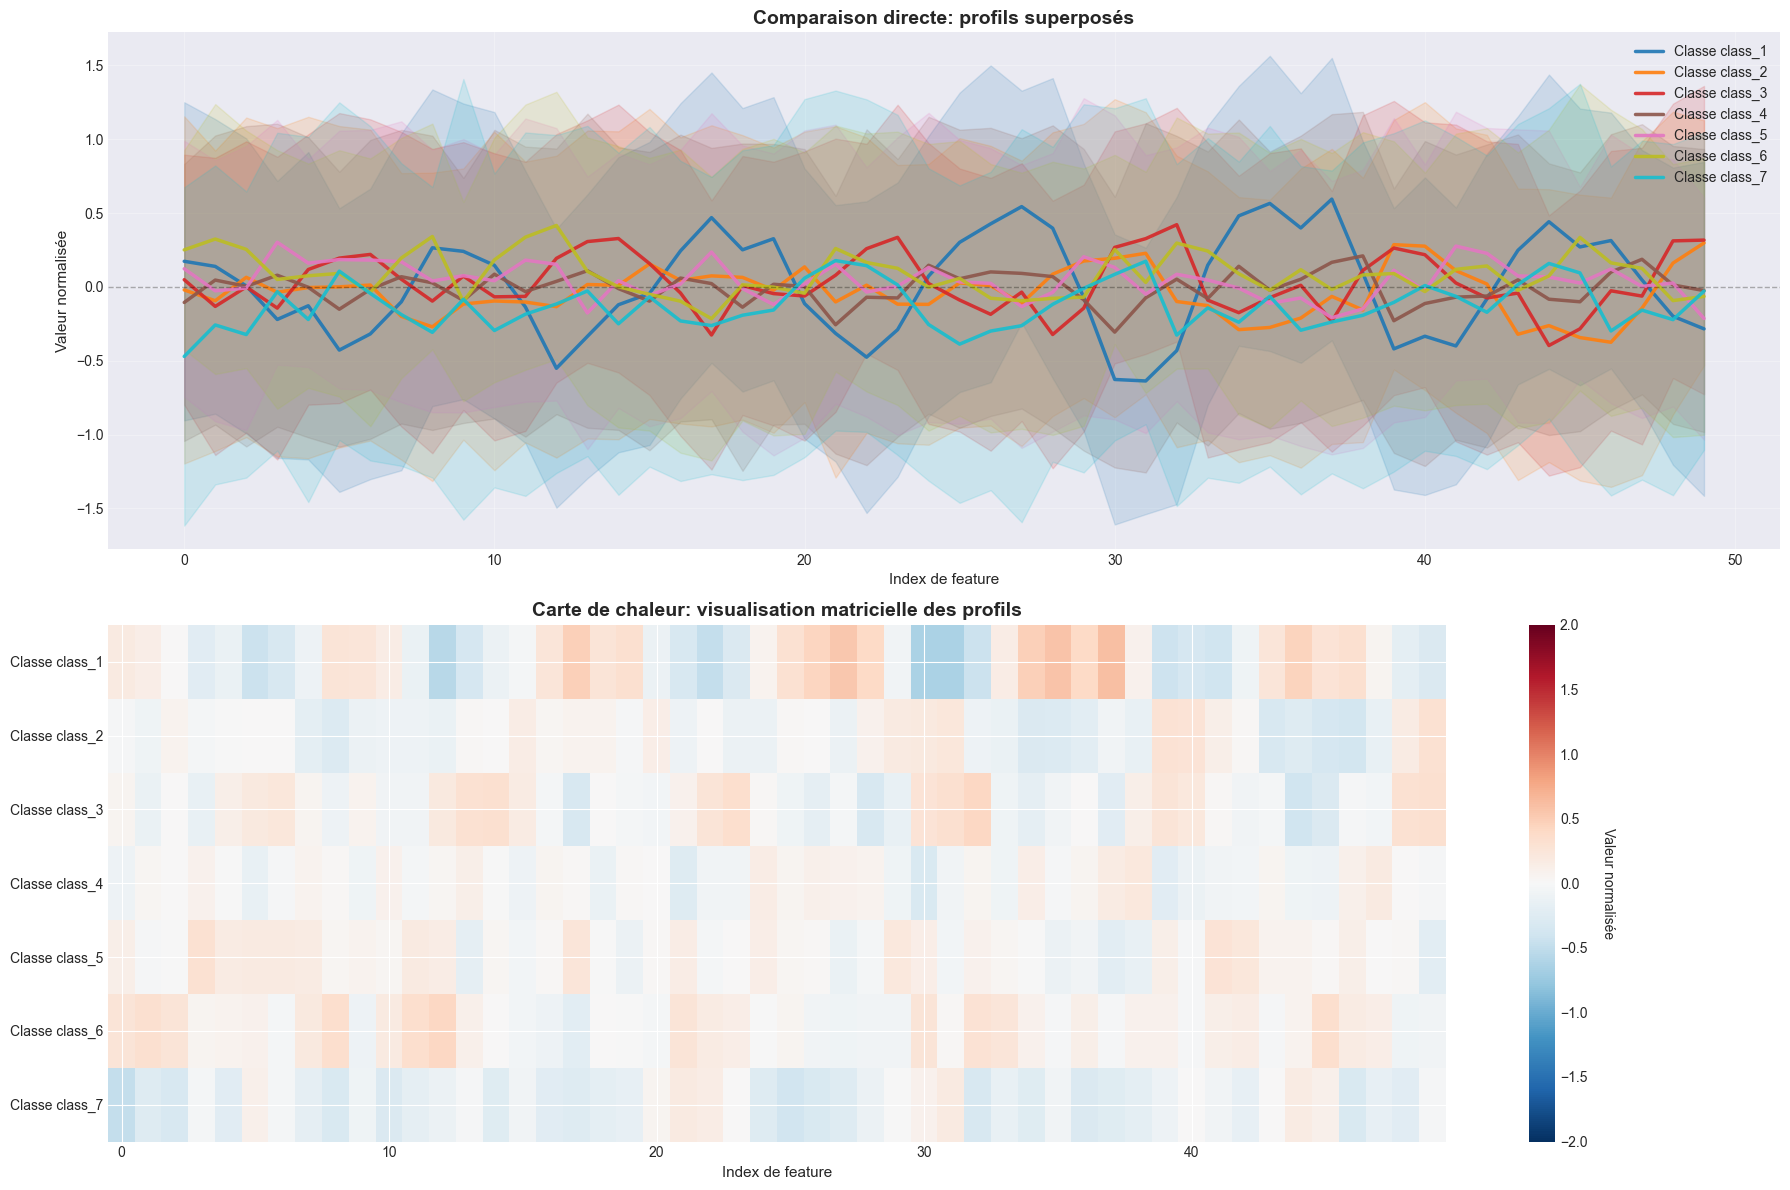


Analyse des différences entre classes:

Paires les PLUS SIMILAIRES (profils proches):
  class_5↔class_6: distance = 1.224
  class_4↔class_5: distance = 1.358
  class_2↔class_3: distance = 1.468

Paires les PLUS DIFFÉRENTES (profils distincts):
  class_1↔class_2: distance = 3.156 ✓
  class_1↔class_7: distance = 3.225 ✓
  class_1↔class_3: distance = 3.555 ✓

Features avec la plus grande variation entre classes:
  1. Feature #30 - variance: 0.0978
  2. Feature #31 - variance: 0.0862
  3. Feature #32 - variance: 0.0825
  4. Feature #12 - variance: 0.0815
  5. Feature #37 - variance: 0.0771
  6. Feature #17 - variance: 0.0718
  7. Feature #44 - variance: 0.0662
  8. Feature #34 - variance: 0.0615
  9. Feature #35 - variance: 0.0597
  10. Feature #27 - variance: 0.0590


In [100]:
# Superposition des profils pour comparaison directe

print("Superposition des profils de classes pour comparaison\n")

# Créer une palette de couleurs distinctes
colors_profiles = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

# Figure principale : superposition
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))

# Plot 1: Profils moyens superposés
x = np.arange(50)
for i, class_name in enumerate(class_names):
    mean_profile = class_profiles[class_name]['mean'][:50]
    std_profile = class_profiles[class_name]['std'][:50]
    
    # Ligne moyenne
    ax1.plot(x, mean_profile, linewidth=2.5, label=f'Classe {class_name}', 
             color=colors_profiles[i], alpha=0.9)
    
    # Zone d'incertitude
    ax1.fill_between(x, 
                      mean_profile - std_profile, 
                      mean_profile + std_profile,
                      alpha=0.15, color=colors_profiles[i])

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax1.set_title('Comparaison directe: profils superposés', fontweight='bold', fontsize=14)
ax1.set_xlabel('Index de feature', fontsize=11)
ax1.set_ylabel('Valeur normalisée', fontsize=11)
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Plot 2: Heatmap des profils
profiles_matrix = np.array([class_profiles[cn]['mean'][:50] for cn in class_names])

im = ax2.imshow(profiles_matrix, aspect='auto', cmap='RdBu_r', 
                interpolation='nearest', vmin=-2, vmax=2)
ax2.set_yticks(range(len(class_names)))
ax2.set_yticklabels([f'Classe {cn}' for cn in class_names], fontsize=10)
ax2.set_xlabel('Index de feature', fontsize=11)
ax2.set_title('Carte de chaleur: visualisation matricielle des profils', 
              fontweight='bold', fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Valeur normalisée', rotation=270, labelpad=20, fontsize=10)

plt.tight_layout()
plt.show()

# Analyse des différences les plus marquées
print("\nAnalyse des différences entre classes:")
print("=" * 70)

# Calculer les distances entre profils
from scipy.spatial.distance import euclidean

profile_distances = {}
for i, class1 in enumerate(class_names):
    for j, class2 in enumerate(class_names):
        if i < j:
            dist = euclidean(class_profiles[class1]['mean'][:50], 
                           class_profiles[class2]['mean'][:50])
            profile_distances[f'{class1}↔{class2}'] = dist

# Trier par distance
sorted_pairs = sorted(profile_distances.items(), key=lambda x: x[1])

print("\nPaires les PLUS SIMILAIRES (profils proches):")
for pair, dist in sorted_pairs[:3]:
    print(f"  {pair}: distance = {dist:.3f}")

print("\nPaires les PLUS DIFFÉRENTES (profils distincts):")
for pair, dist in sorted_pairs[-3:]:
    print(f"  {pair}: distance = {dist:.3f} ✓")

# Identifier les features les plus discriminantes
print("\nFeatures avec la plus grande variation entre classes:")
feature_variance_across_classes = profiles_matrix.var(axis=0)
top_varying_features = np.argsort(feature_variance_across_classes)[-10:][::-1]

for rank, feat_idx in enumerate(top_varying_features, 1):
    var_val = feature_variance_across_classes[feat_idx]
    print(f"  {rank}. Feature #{feat_idx:2d} - variance: {var_val:.4f}")

Analyse des distances entre classes



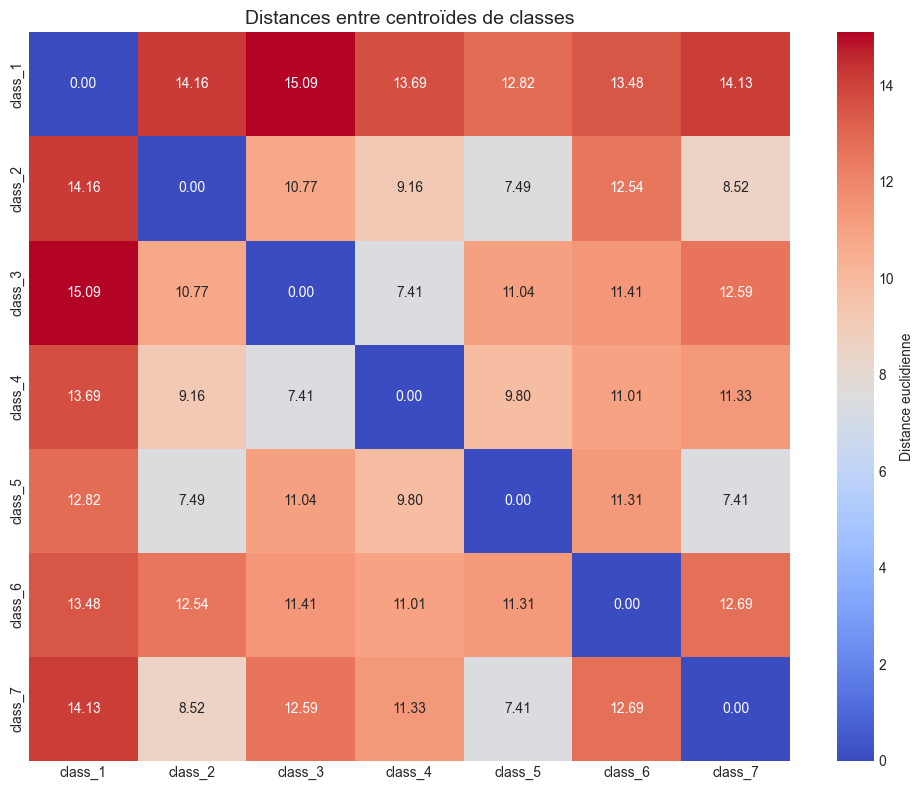


Paires de classes:

Plus similaires (risque de confusion):
  class_5 ↔ class_7: distance = 7.41
  class_3 ↔ class_4: distance = 7.41
  class_2 ↔ class_5: distance = 7.49

Plus différentes (bien séparées):
  class_1 ↔ class_7: distance = 14.13
  class_1 ↔ class_2: distance = 14.16
  class_1 ↔ class_3: distance = 15.09


In [101]:
# Distances inter-classes : comprendre la séparabilité

print("Analyse des distances entre classes\n")

# Calculer les centroïdes de chaque classe
centroids = {}
for class_name in class_names:
    mask = labels == class_name
    centroids[class_name] = features_scaled[mask].mean(axis=0)

# Matrice de distances
n_classes = len(class_names)
distance_matrix = np.zeros((n_classes, n_classes))

for i, class1 in enumerate(class_names):
    for j, class2 in enumerate(class_names):
        dist = euclidean(centroids[class1], centroids[class2])
        distance_matrix[i, j] = dist

# Visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Distance euclidienne'})
plt.title('Distances entre centroïdes de classes', fontsize=14)
plt.tight_layout()
plt.show()

print("\nPaires de classes:")
pairs = []
for i in range(n_classes):
    for j in range(i+1, n_classes):
        pairs.append((class_names[i], class_names[j], distance_matrix[i, j]))

pairs.sort(key=lambda x: x[2])
print("\nPlus similaires (risque de confusion):")
for c1, c2, d in pairs[:3]:
    print(f"  {c1} ↔ {c2}: distance = {d:.2f}")

print("\nPlus différentes (bien séparées):")
for c1, c2, d in pairs[-3:]:
    print(f"  {c1} ↔ {c2}: distance = {d:.2f}")


Requête depuis la classe: class_1


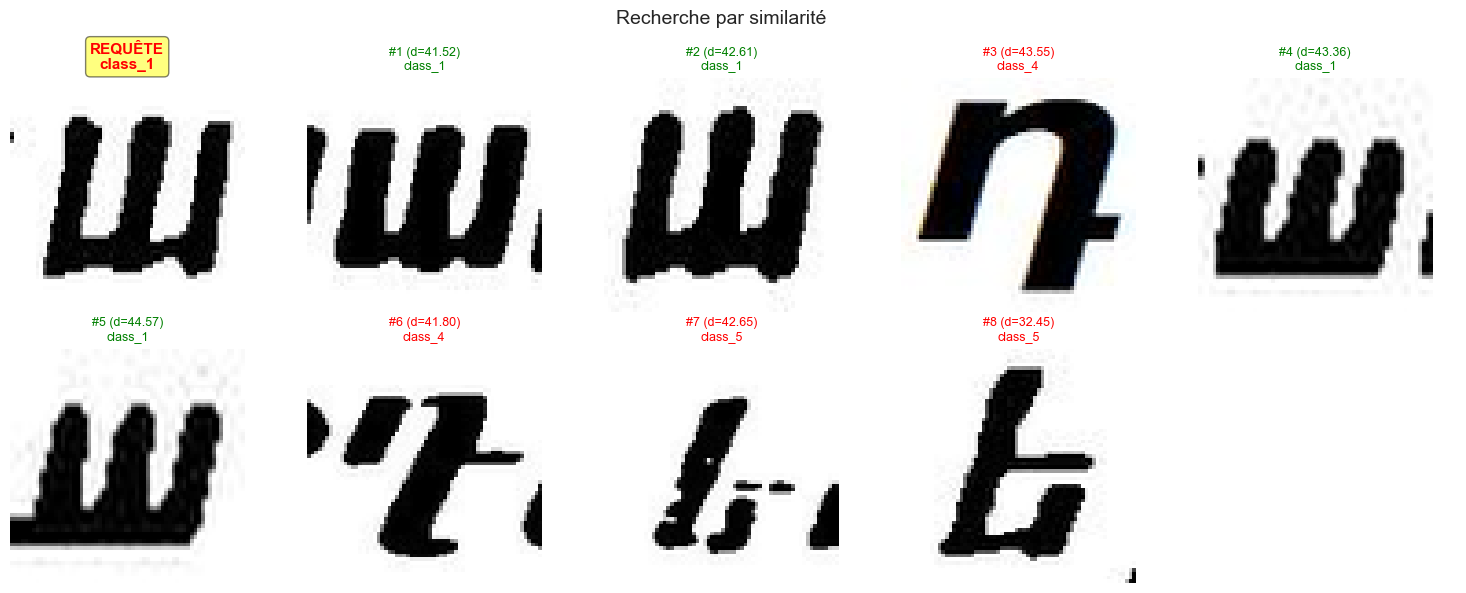


Résultats:
  Classe de la requête: class_1
  Voisins de même classe: 4/8 (50%)

Requête depuis la classe: class_2


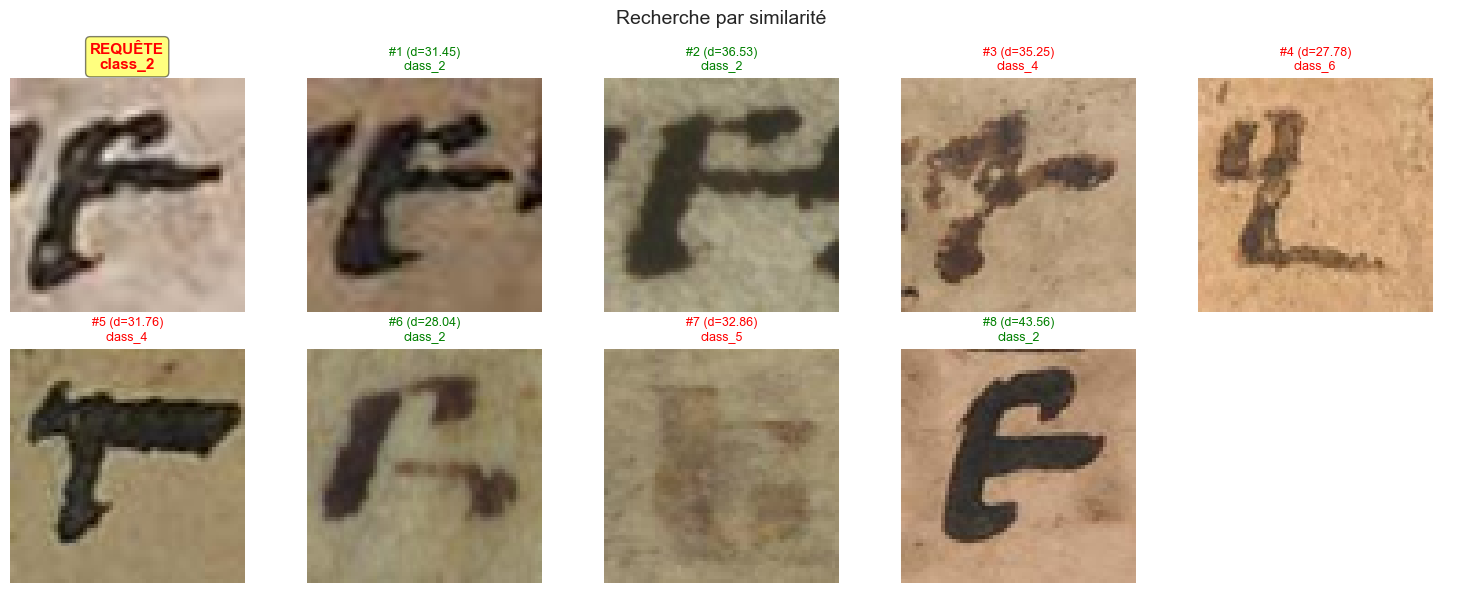


Résultats:
  Classe de la requête: class_2
  Voisins de même classe: 4/8 (50%)

Requête depuis la classe: class_3


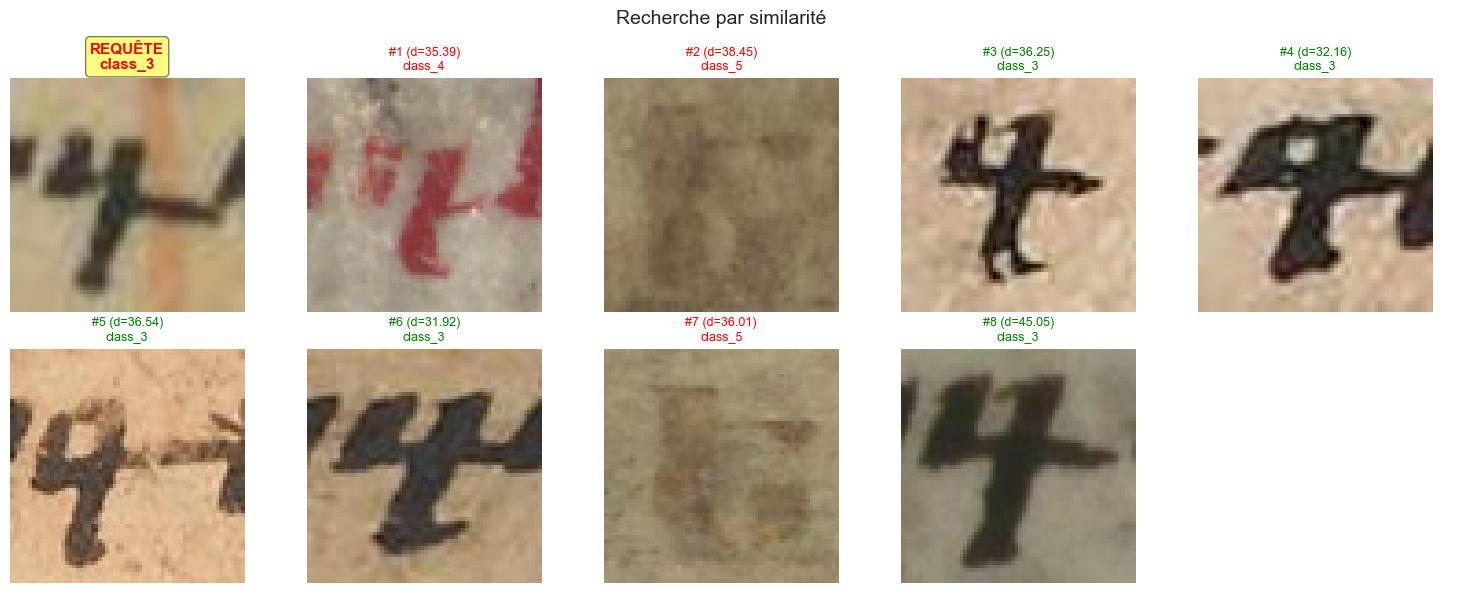


Résultats:
  Classe de la requête: class_3
  Voisins de même classe: 5/8 (62%)


In [102]:
# Recherche par similarité : exemples de requêtes

def find_similar_images_viz(query_idx, features, images_array, labels_array, k=8):
    """
    Trouve et visualise les images similaires
    """
    from scipy.spatial.distance import cdist
    
    query_feature = features[query_idx].reshape(1, -1)
    distances = cdist(query_feature, features, metric='euclidean').flatten()
    
    # Trier (exclure l'image elle-même)
    similar_indices = np.argsort(distances)[1:k+1]
    similar_distances = distances[similar_indices]
    
    # Visualisation
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    # Image requête
    axes[0].imshow(images_array[query_idx])
    axes[0].set_title(f'REQUÊTE\n{labels_array[query_idx]}', 
                      fontsize=11, fontweight='bold', 
                      color='red', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    axes[0].axis('off')
    
    # Images similaires
    for i, (idx, dist) in enumerate(zip(similar_indices, distances)):
        axes[i+1].imshow(images_array[idx])
        color = 'green' if labels_array[idx] == labels_array[query_idx] else 'red'
        axes[i+1].set_title(f'#{i+1} (d={dist:.2f})\n{labels_array[idx]}', 
                           fontsize=9, color=color)
        axes[i+1].axis('off')
    
    axes[9].axis('off')
    
    plt.suptitle('Recherche par similarité', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    same_class = sum([labels_array[idx] == labels_array[query_idx] for idx in similar_indices])
    print(f"\nRésultats:")
    print(f"  Classe de la requête: {labels_array[query_idx]}")
    print(f"  Voisins de même classe: {same_class}/{k} ({same_class/k*100:.0f}%)")
    

# Tester avec plusieurs exemples
for class_name in class_names[:min(3, len(class_names))]:
    class_indices = np.where(labels == class_name)[0]
    if len(class_indices) > 0:
        query_idx = np.random.choice(class_indices)
        print(f"\nRequête depuis la classe: {class_name}")
        find_similar_images_viz(query_idx, features_scaled, images, labels, k=8)